# Problem Statement: Analysis of Student Dropout Determinants in Kenyan Higher Education

## 1. Background & Context
Student dropout from higher education institutions is a critical challenge in Kenya, leading to significant individual, social, and economic costs. These include wasted educational resources, reduced skilled workforce, increased unemployment, and lower lifetime earnings for the individuals who drop out. Understanding the multifaceted factors that contribute to this phenomenon is essential for developing effective, data-driven retention strategies. This dataset captures information on 118,000+ students, providing a rich opportunity to explore the complex interplay of academic, financial, demographic, and engagement-related factors.

## 2. Problem Identification
The core problem is the unexplained and unmitigated student dropout phenomenon in the Kenyan higher education context. Specifically, we investigate:
- What is the primary driver of dropout: academic preparedness, current performance, or financial constraints?
- How do financial factors interact with academic factors to influence dropout risk?
- Does the impact vary significantly by demographics, programme of study, or engagement levels?
- Can a predictive model identify students at high risk of dropping out early?

## 3. Objectives
1. **Descriptive Analysis** — Profile the student population and compare characteristics of dropouts vs. persisters.
2. **Exploratory Analysis** — Investigate relationships between independent variables and dropout status.
3. **Predictive Modelling** — Develop and evaluate a stacking classifier to predict dropout risk.
4. **Actionable Insights** — Translate findings into recommendations for administrators and policymakers.

## 1. Imports

In [213]:
# Core libraries
import pandas as pd
import numpy as np
from datetime import datetime

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm

# Statistics
from scipy.stats import chi2_contingency, ttest_ind

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
!pip install imblearn
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier

# Model selection
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV
)

# Metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, f1_score, recall_score
)

# Pipeline
from sklearn.pipeline import Pipeline

# Warnings
import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading

In [214]:
School_df = pd.read_csv("student.csv")
School_df.head()

,Gender,Birthdate,PHYSICALLYCHALLENGED,County,Loan_serial_number,ScholarshipApplied,InstitutionCode,InstitutionName,COURSECODE,ProgramCost,...,Category,applicanttype,LoanStatus,Unnamed: 21,Mother_Age,Father_Age,Father_educ_level,Mother_educ_level,Highest_educ_level,Drop_out
0,Male,13/03/1996,0,MIGORI,2510374563,0,KPU,TECHNICAL UNIVERSITY OF KENYA,EEEI,270000.0,...,PublicUniversityGovtSponsored,1,Partially Disbursed,NaN,69,64,Primary,Primary,Primary,0
1,Male,08/07/1982,0,NaN,2510057518,0,CA,Catholic University,BED,160000.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,63,65,Diploma,Secondary,Diploma,1
2,Male,18/02/1993,0,NaN,2510233585,0,MTK,Mount Kenya University,BBIT,111000.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,54,57,Primary,Secondary,Secondary,0
3,Male,18/03/1986,0,NaN,2510031694,0,KAFUCO,Kaimosi Friends University,HNR,275400.0,...,PublicUniversitySelfSponsored,1,Allocated,NaN,51,76,Diploma,Primary,Diploma,0
4,Male,31/10/1987,0,NAKURU,2510438107,0,UBG,Bugema University,BHT,0.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,58,64,Secondary,Secondary,Secondary,0


In [215]:
print(School_df.shape)
School_df.info()

(118259, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118259 entries, 0 to 118258
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                62659 non-null   object 
 1   Birthdate             118259 non-null  object 
 2   PHYSICALLYCHALLENGED  118259 non-null  int64  
 3   County                118235 non-null  object 
 4   Loan_serial_number    118259 non-null  int64  
 5   ScholarshipApplied    118259 non-null  int64  
 6   InstitutionCode       118259 non-null  object 
 7   InstitutionName       118259 non-null  object 
 8   COURSECODE            117794 non-null  object 
 9   ProgramCost           117794 non-null  float64
 10  CourseCategory        114059 non-null  object 
 11  Adm No                118233 non-null  object 
 12  ExamYear              118259 non-null  int64  
 13  INDEXNUMBER           118258 non-null  object 
 14  TotalLoanAllocated    118259 non-null  

In [216]:
School_df.isna().sum()

Gender                   55600
Birthdate                    0
PHYSICALLYCHALLENGED         0
County                      24
Loan_serial_number           0
ScholarshipApplied           0
InstitutionCode              0
InstitutionName              0
COURSECODE                 465
ProgramCost                465
CourseCategory            4200
Adm No                      26
ExamYear                     0
INDEXNUMBER                  1
TotalLoanAllocated           0
LoanproductCode              0
BursaryAllocated             0
BURSARYBATCHNUMBER      118259
Category                     0
applicanttype                0
LoanStatus                   3
Unnamed: 21             118259
Mother_Age                   0
Father_Age                   0
Father_educ_level        16817
Mother_educ_level        20568
Highest_educ_level       13548
Drop_out                     0
dtype: int64

## 3. Data Cleaning

### 3.1 Drop Irrelevant Columns

In [217]:
columns_to_drop = [
    'BURSARYBATCHNUMBER', 'Unnamed: 21', 'PHYSICALLYCHALLENGED',
    'Loan_serial_number', 'InstitutionCode', 'Adm No',
    'COURSECODE', 'INDEXNUMBER', 'BursaryAllocated', 'applicanttype'
]
School_df = School_df.drop(columns=columns_to_drop, errors='ignore')
School_df.columns

Index(['Gender', 'Birthdate', 'County', 'ScholarshipApplied',
       'InstitutionName', 'ProgramCost', 'CourseCategory', 'ExamYear',
       'TotalLoanAllocated', 'LoanproductCode', 'Category', 'LoanStatus',
       'Mother_Age', 'Father_Age', 'Father_educ_level', 'Mother_educ_level',
       'Highest_educ_level', 'Drop_out'],
      dtype='object')

### 3.2 Drop Rows with Missing Values in Key Columns

In [218]:
School_df = School_df.dropna(subset=[
    "Gender", "County", "ProgramCost", "CourseCategory",
    "Father_educ_level", "Mother_educ_level", "LoanStatus", "Highest_educ_level"
])
School_df.isna().sum()

Gender                0
Birthdate             0
County                0
ScholarshipApplied    0
InstitutionName       0
ProgramCost           0
CourseCategory        0
ExamYear              0
TotalLoanAllocated    0
LoanproductCode       0
Category              0
LoanStatus            0
Mother_Age            0
Father_Age            0
Father_educ_level     0
Mother_educ_level     0
Highest_educ_level    0
Drop_out              0
dtype: int64

### 3.3 Remove Unsupported Loan Product Codes

In [219]:
School_df = School_df[
    ~School_df['LoanproductCode'].isin(['DL6', 'VC'])
]
School_df['LoanproductCode'].value_counts()

LoanproductCode
UG    47652
Name: count, dtype: int64

### 3.4 Remove Duplicates

In [220]:
print("Duplicates before:", School_df.duplicated().sum())
School_df = School_df.drop_duplicates()
print("Duplicates after:", School_df.duplicated().sum())

Duplicates before: 6
Duplicates after: 0


## 4. Feature Engineering

### Assumptions
- Age 16+ is eligible to join an undergraduate programme.

### 4.1 Create Age Column

In [221]:
# Convert Birthdate to datetime and derive age
School_df["Birthdate"] = pd.to_datetime(School_df["Birthdate"], errors="coerce")
today = datetime.today()
School_df["age"] = School_df["Birthdate"].apply(
    lambda x: today.year - x.year - ((today.month, today.day) < (x.month, x.day))
    if pd.notnull(x) else None
)

### 4.2 Extract University Type and Sponsorship from Category

In [222]:
School_df[['UniversityType', 'Sponsored']] = School_df['Category'].str.extract(
    r'^(Public|Private).*?(GovtSponsored|SelfSponsored)$'
)
School_df[['UniversityType', 'Sponsored']].value_counts()

UniversityType  Sponsored    
Public          GovtSponsored    41972
Private         SelfSponsored     3699
Public          SelfSponsored     1132
Private         GovtSponsored      843
Name: count, dtype: int64

### 4.3 Create Age Groups

In [223]:
bins   = [0, 18, 21, 25]
labels = ['<17', '18-21', '22-25']
School_df['age_group'] = pd.cut(School_df['age'], bins=bins, labels=labels)
School_df['age_group'].value_counts()

age_group
18-21    35749
<17       5910
22-25     5338
Name: count, dtype: int64

### 4.4 Export Cleaned Dataset

In [224]:
School_df.to_csv('cleaned.csv', index=False)
print(f"Cleaned dataset saved: {School_df.shape[0]} rows, {School_df.shape[1]} columns")

Cleaned dataset saved: 47646 rows, 22 columns


## 5. Exploratory Data Analysis

### 5.1 Age Distribution

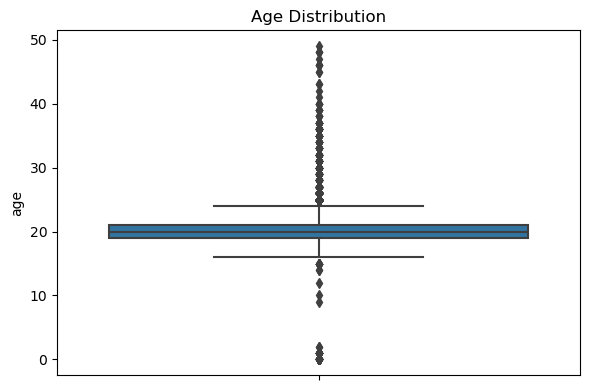

In [225]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=School_df['age'])
plt.title('Age Distribution')
plt.tight_layout()
plt.show()

In [226]:
# Filter to valid student age range to deal with
School_df = School_df[School_df['age'] >= 17]
School_df = School_df[(School_df['age'] >= 16) & (School_df['age'] <= 25)]
School_df['age'].describe()

count    46883.000000
mean        19.803895
std          1.372708
min         17.000000
25%         19.000000
50%         20.000000
75%         20.000000
max         25.000000
Name: age, dtype: float64

In [227]:
School_df.age.value_counts()

age
19.0    17195
20.0    12179
21.0     6375
18.0     5126
22.0     3187
23.0     1343
17.0      670
24.0      555
25.0      253
Name: count, dtype: int64

### 5.2 School Drop Out Rate by County in Kenya

In [228]:
# 1. Standardize to uppercase and strip whitespace
School_df['County'] = School_df['County'].astype(str).str.upper().str.strip()

# 2. Cleanup punctuation and spacing
# We replace slashes and hyphens with spaces, but we'll handle the apostrophe carefully
School_df['County'] = School_df['County'].str.replace(r'[-/]', ' ', regex=True)
School_df['County'] = School_df['County'].str.replace(r'\s+', ' ', regex=True)

# 3. Specific fix for Murang'a and other duplicates
mapping = {
    'MURANG A': "MURANG'A",
    'MURANGA': "MURANG'A",
    'TRANSNZOIA': 'TRANS NZOIA'
}

School_df['County'] = School_df['County'].replace(mapping)

# 4. Verification
unique_counties = sorted(School_df['County'].unique())
print(f"Unique County Count: {len(unique_counties)}")
print(unique_counties)

Unique County Count: 47
['BARINGO', 'BOMET', 'BUNGOMA', 'BUSIA', 'ELGEYO MARAKWET', 'EMBU', 'GARISSA', 'HOMA BAY', 'ISIOLO', 'KAJIADO', 'KAKAMEGA', 'KERICHO', 'KIAMBU', 'KILIFI', 'KIRINYAGA', 'KISII', 'KISUMU', 'KITUI', 'KWALE', 'LAIKIPIA', 'LAMU', 'MACHAKOS', 'MAKUENI', 'MANDERA', 'MARSABIT', 'MERU', 'MIGORI', 'MOMBASA', "MURANG'A", 'NAIROBI', 'NAKURU', 'NANDI', 'NAROK', 'NYAMIRA', 'NYANDARUA', 'NYERI', 'SAMBURU', 'SIAYA', 'TAITA TAVETA', 'TANA RIVER', 'THARAKA NITHI', 'TRANS NZOIA', 'TURKANA', 'UASIN GISHU', 'VIHIGA', 'WAJIR', 'WEST POKOT']


In [229]:
School_df.County.unique()

array(['KAKAMEGA', 'KAJIADO', 'NAIROBI', 'KIAMBU', 'KITUI', 'MACHAKOS',
       'UASIN GISHU', 'MOMBASA', 'MIGORI', 'ELGEYO MARAKWET', 'BUNGOMA',
       'NYAMIRA', 'KILIFI', 'BOMET', 'TRANS NZOIA', 'KISUMU', 'HOMA BAY',
       'MERU', 'THARAKA NITHI', 'KWALE', "MURANG'A", 'NYERI', 'BUSIA',
       'NAKURU', 'KISII', 'KIRINYAGA', 'NANDI', 'VIHIGA', 'SIAYA',
       'MAKUENI', 'NYANDARUA', 'TAITA TAVETA', 'LAIKIPIA', 'KERICHO',
       'LAMU', 'NAROK', 'SAMBURU', 'BARINGO', 'EMBU', 'WEST POKOT',
       'GARISSA', 'MARSABIT', 'TURKANA', 'TANA RIVER', 'ISIOLO',
       'MANDERA', 'WAJIR'], dtype=object)

In [230]:
# Create the summary table
dropout_table = School_df.groupby('County').agg(
    Total_Students = ('Drop_out', 'count'),
    Dropout_Count  = ('Drop_out', 'sum')
).reset_index()

# Calculate dropout percentage
dropout_table['Dropout_Percentage'] = (
    dropout_table['Dropout_Count'] / dropout_table['Total_Students'] * 100
).round(2)

# Sort by highest dropout percentage
dropout_table = dropout_table.sort_values('Dropout_Percentage', ascending=False)

# Reset index cleanly
dropout_table = dropout_table.reset_index(drop=True)

print(dropout_table)

             County  Total_Students  Dropout_Count  Dropout_Percentage
0           MANDERA              21              9               42.86
1             WAJIR              28             11               39.29
2          MARSABIT              90             34               37.78
3              LAMU              60             22               36.67
4           SAMBURU              73             25               34.25
5         KIRINYAGA             373            125               33.51
6              EMBU             447            149               33.33
7            KISUMU            1858            594               31.97
8       TRANS NZOIA            1236            395               31.96
9           NYAMIRA            1725            546               31.65
10            BOMET            1387            436               31.43
11          BUNGOMA            2080            644               30.96
12            BUSIA            1295            400               30.89
13    

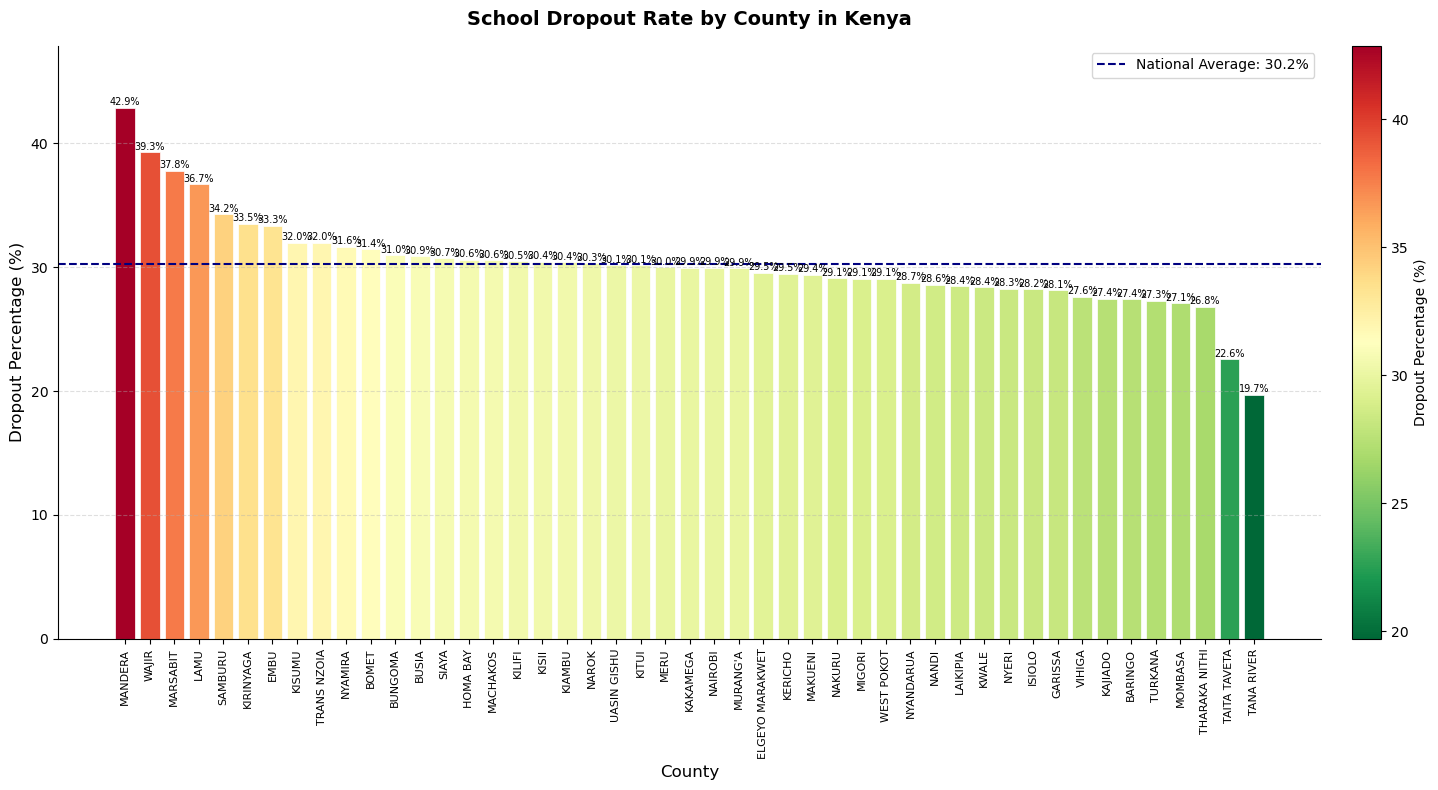

In [231]:
# Sort by percentage highest to lowest
dropout_plot = dropout_table.sort_values('Dropout_Percentage', ascending=False).reset_index(drop=True)

# Create colour gradient — green (low) to red (high)
norm = plt.Normalize(
    dropout_plot['Dropout_Percentage'].min(),
    dropout_plot['Dropout_Percentage'].max()
)
colors = cm.RdYlGn_r(norm(dropout_plot['Dropout_Percentage']))

# Create the figure
fig, ax = plt.subplots(figsize=(16, 8))

# Plot vertical bar chart with gradient colours
bars = ax.bar(
    dropout_plot['County'],
    dropout_plot['Dropout_Percentage'],
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

# Add percentage labels on top of each bar
for bar, val in zip(bars, dropout_plot['Dropout_Percentage']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{val:.1f}%',
        ha='center',
        fontsize=7
    )

# Add colourbar legend
sm = cm.ScalarMappable(cmap='RdYlGn_r', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Dropout Percentage (%)', fontsize=10)

# Formatting
ax.set_ylabel('Dropout Percentage (%)', fontsize=12)
ax.set_xlabel('County', fontsize=12)
ax.set_title('School Dropout Rate by County in Kenya', fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, dropout_plot['Dropout_Percentage'].max() + 5)
ax.axhline(
    dropout_table['Dropout_Percentage'].mean(),
    color='navy', linestyle='--', linewidth=1.5,
    label=f"National Average: {dropout_table['Dropout_Percentage'].mean():.1f}%"
)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

In [232]:
#Create the summary table by ExamYear
dropout_year_table = School_df.groupby('ExamYear').agg(
    Total_Students = ('Drop_out', 'count'),
    Dropout_Count  = ('Drop_out', 'sum')
).reset_index()

# Calculate dropout percentage
dropout_year_table['Dropout_Percentage'] = (
    dropout_year_table['Dropout_Count'] / dropout_year_table['Total_Students'] * 100
).round(2)

# Sort by ExamYear
dropout_year_table = dropout_year_table.sort_values('ExamYear', ascending=True).reset_index(drop=True)

print(dropout_year_table)

   ExamYear  Total_Students  Dropout_Count  Dropout_Percentage
0      2016               1              0                0.00
1      2017              18              8               44.44
2      2018              50             14               28.00
3      2019             146             38               26.03
4      2020             362            117               32.32
5      2021            1098            320               29.14
6      2022             680            198               29.12
7      2023            2273            662               29.12
8      2024           42255          12745               30.16


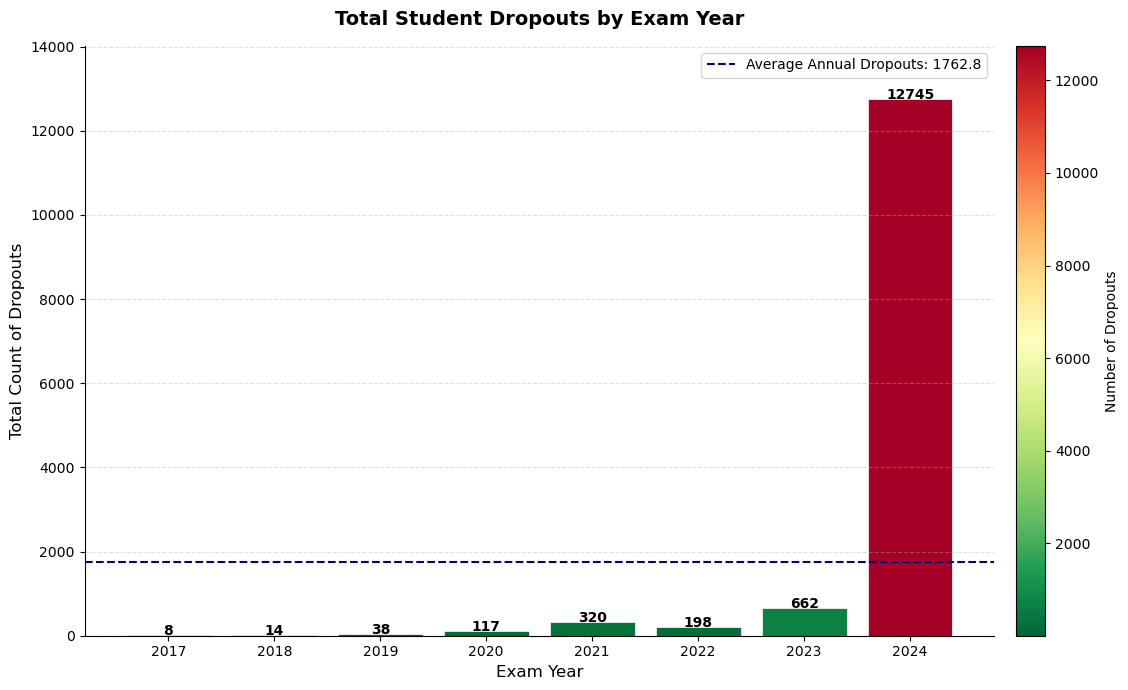

In [233]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 1. Prepare the data: Count the number of dropouts per year
# We filter the dataframe for only dropouts and then group by year
dropout_counts = School_df[School_df['Drop_out'] == 1].groupby('ExamYear').size().reset_index(name='Dropout_Count')

# 2. Plotting logic
fig, ax = plt.subplots(figsize=(12, 7))

# Normalization for the color map based on counts
norm = plt.Normalize(
    dropout_counts['Dropout_Count'].min(),
    dropout_counts['Dropout_Count'].max()
)
colors = cm.RdYlGn_r(norm(dropout_counts['Dropout_Count']))

bars = ax.bar(
    dropout_counts['ExamYear'].astype(str),
    dropout_counts['Dropout_Count'],
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

# Add count labels on top of each bar
for bar, val in zip(bars, dropout_counts['Dropout_Count']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{int(val)}',  # Displaying as integer count
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Colourbar updated for counts
sm = cm.ScalarMappable(cmap='RdYlGn_r', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Number of Dropouts', fontsize=10)

# Labels and Title
ax.set_ylabel('Total Count of Dropouts', fontsize=12)
ax.set_xlabel('Exam Year', fontsize=12)
ax.set_title('Total Student Dropouts by Exam Year', fontsize=14, fontweight='bold', pad=15)

# Update Y-limit to provide space for labels
ax.set_ylim(0, dropout_counts['Dropout_Count'].max() * 1.1)

# Horizontal line for the average annual count
avg_count = dropout_counts['Dropout_Count'].mean()
ax.axhline(
    avg_count,
    color='navy', linestyle='--', linewidth=1.5,
    label=f"Average Annual Dropouts: {avg_count:.1f}"
)

ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [234]:
School_df.shape

(46883, 22)

In [235]:
# 1. (Optional but recommended) Ensure ExamYear is numeric to avoid type errors
School_df['ExamYear'] = pd.to_numeric(School_df['ExamYear'], errors='coerce')

# 2. Filter for the year 2024
School_df = School_df[School_df['ExamYear'] == 2024]

# 3. Check the results
print(f"Rows after filtering: {len(School_df)}")
print(f"Unique years in data: {School_df['ExamYear'].unique()}")

Rows after filtering: 42255
Unique years in data: [2024]


### 5.3 Age Group vs Dropout

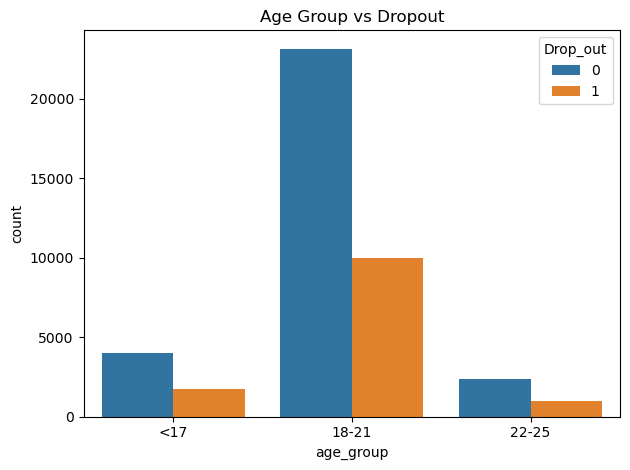

In [236]:
sns.countplot(x='age_group', hue='Drop_out', data=School_df)
plt.title('Age Group vs Dropout')
plt.tight_layout()
plt.show()

### 5.4 Loan-to-Cost Ratio by University Type

# Remove Outliers

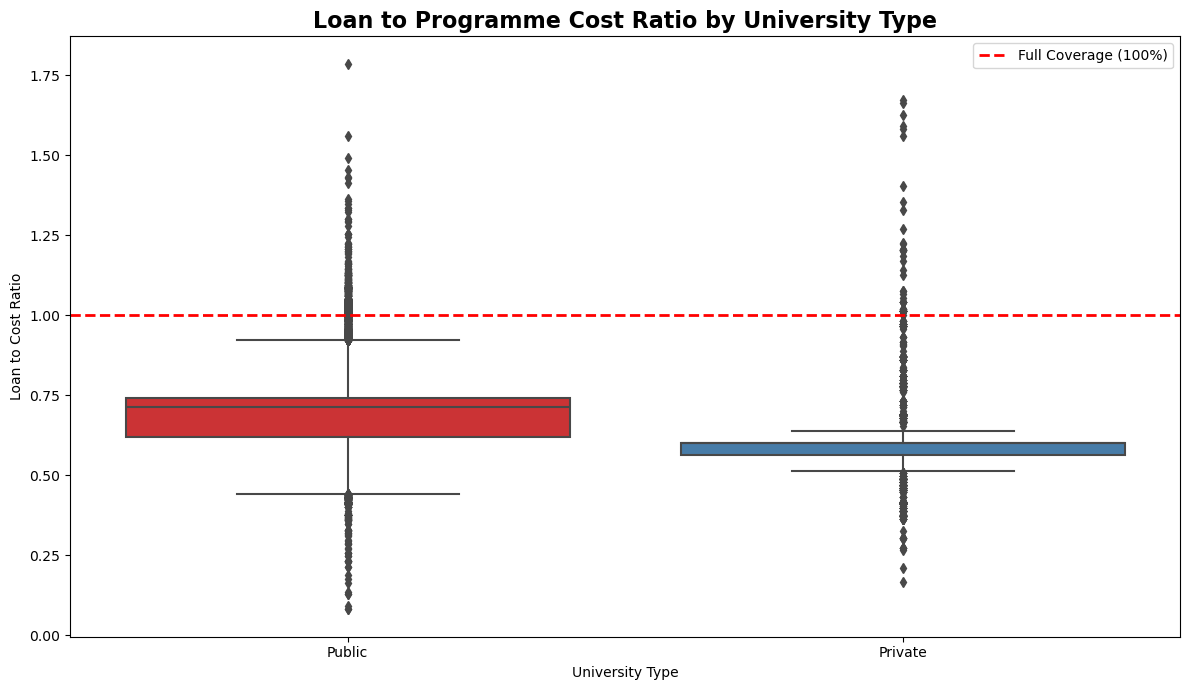

In [237]:
df_ratio = School_df.dropna(subset=['ProgramCost', 'TotalLoanAllocated']).copy()
df_ratio = df_ratio[df_ratio['ProgramCost'] > 0]
df_ratio['LoanToCostRatio'] = (df_ratio['TotalLoanAllocated'] / df_ratio['ProgramCost']).clip(upper=2)

plt.figure(figsize=(12, 7))
sns.boxplot(x='UniversityType', y='LoanToCostRatio', data=df_ratio, palette='Set1')
plt.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Full Coverage (100%)')
plt.title('Loan to Programme Cost Ratio by University Type', fontsize=16, fontweight='bold')
plt.xlabel('University Type')
plt.ylabel('Loan to Cost Ratio')
plt.legend()
plt.tight_layout()
plt.show()

In [238]:
School_df.columns

Index(['Gender', 'Birthdate', 'County', 'ScholarshipApplied',
       'InstitutionName', 'ProgramCost', 'CourseCategory', 'ExamYear',
       'TotalLoanAllocated', 'LoanproductCode', 'Category', 'LoanStatus',
       'Mother_Age', 'Father_Age', 'Father_educ_level', 'Mother_educ_level',
       'Highest_educ_level', 'Drop_out', 'age', 'UniversityType', 'Sponsored',
       'age_group'],
      dtype='object')

**Interpretation:** Public universities show a higher loan-to-cost ratio due to government support and lower fees.
Private universities have a lower ratio, reflecting higher programme costs relative to loan allocations.

# EDIT ME

### 5.6 Dropout Rate by Age Group

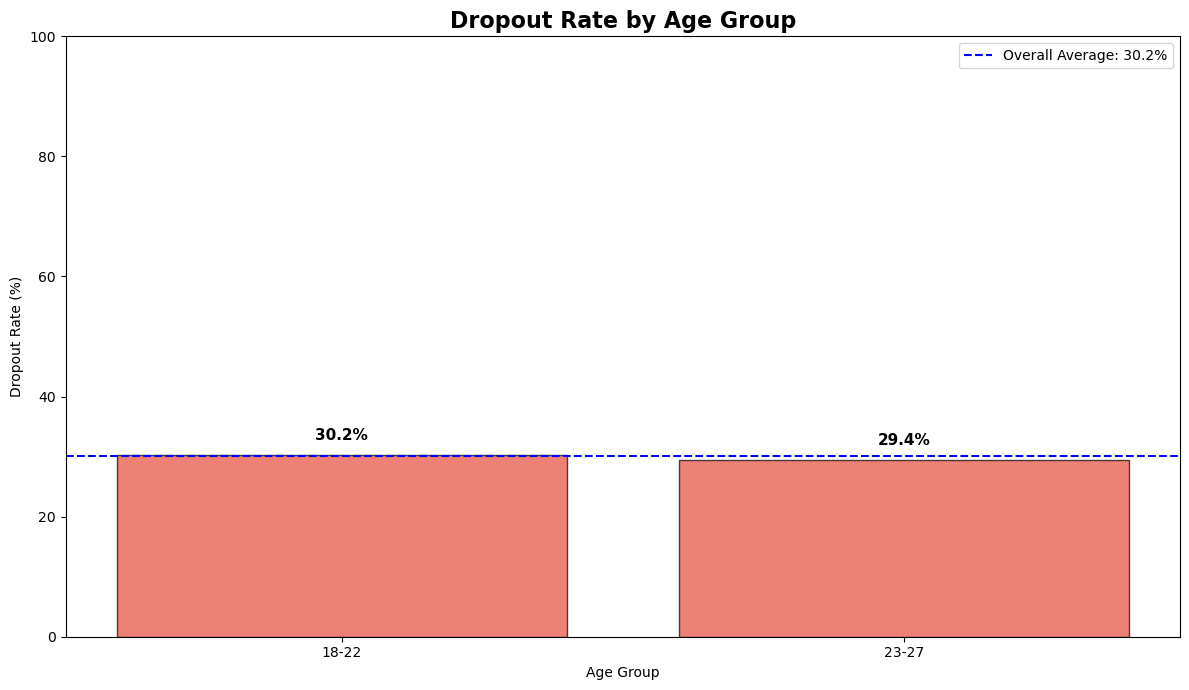

In [239]:
df_age_group = School_df.dropna(subset=['age']).copy()
df_age_group = df_age_group[(df_age_group['age'] >= 18) & (df_age_group['age'] <= 60)]
bins2   = [18, 22, 27, 32, 40, 100]
labels2 = ['18-22', '23-27', '28-32', '33-40', '40+']
df_age_group['AgeGroup'] = pd.cut(df_age_group['age'], bins=bins2, labels=labels2, right=False)
dropout_by_age = df_age_group.groupby('AgeGroup')['Drop_out'].agg(['mean', 'count'])
dropout_by_age = dropout_by_age[dropout_by_age['count'] > 10]

plt.figure(figsize=(12, 7))
bars = plt.bar(range(len(dropout_by_age)), dropout_by_age['mean'] * 100,
               color='#e74c3c', edgecolor='black', alpha=0.7)
plt.xticks(range(len(dropout_by_age)), dropout_by_age.index)
plt.title('Dropout Rate by Age Group', fontsize=16, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Dropout Rate (%)')
plt.ylim(0, 100)
for bar, rate in zip(bars, dropout_by_age['mean']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{rate*100:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
overall = df_age_group['Drop_out'].mean() * 100
plt.axhline(y=overall, color='blue', linestyle='--', label=f'Overall Average: {overall:.1f}%')
plt.legend()
plt.tight_layout()
plt.show()

### 5.7 Scholarship Application & Loan Amount

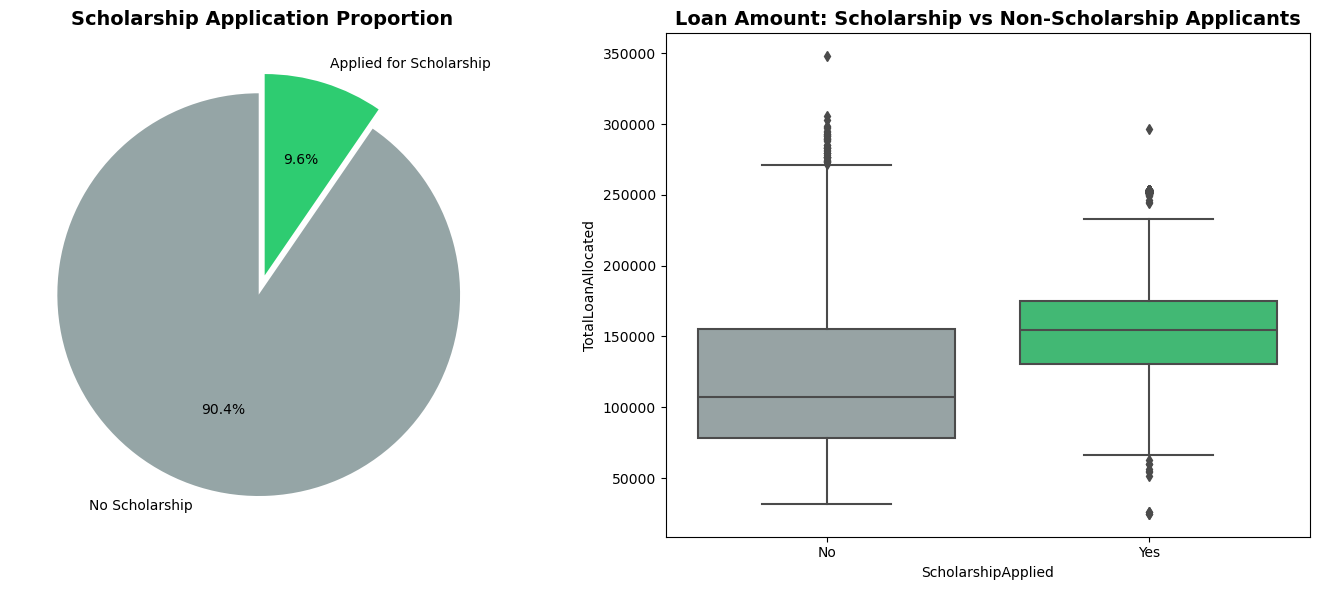

In [240]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scholarship_counts = School_df['ScholarshipApplied'].value_counts()
axes[0].pie(scholarship_counts.values,
            labels=['No Scholarship', 'Applied for Scholarship'],
            autopct='%1.1f%%', colors=['#95a5a6', '#2ecc71'],
            startangle=90, explode=(0.05, 0.05))
axes[0].set_title('Scholarship Application Proportion', fontsize=14, fontweight='bold')

sns.boxplot(x='ScholarshipApplied', y='TotalLoanAllocated', data=School_df,
            ax=axes[1], palette=['#95a5a6', '#2ecc71'])
axes[1].set_title('Loan Amount: Scholarship vs Non-Scholarship Applicants', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['No', 'Yes'])
plt.tight_layout()
plt.show()

### 5.8 Loan Distribution by Demographic Groups

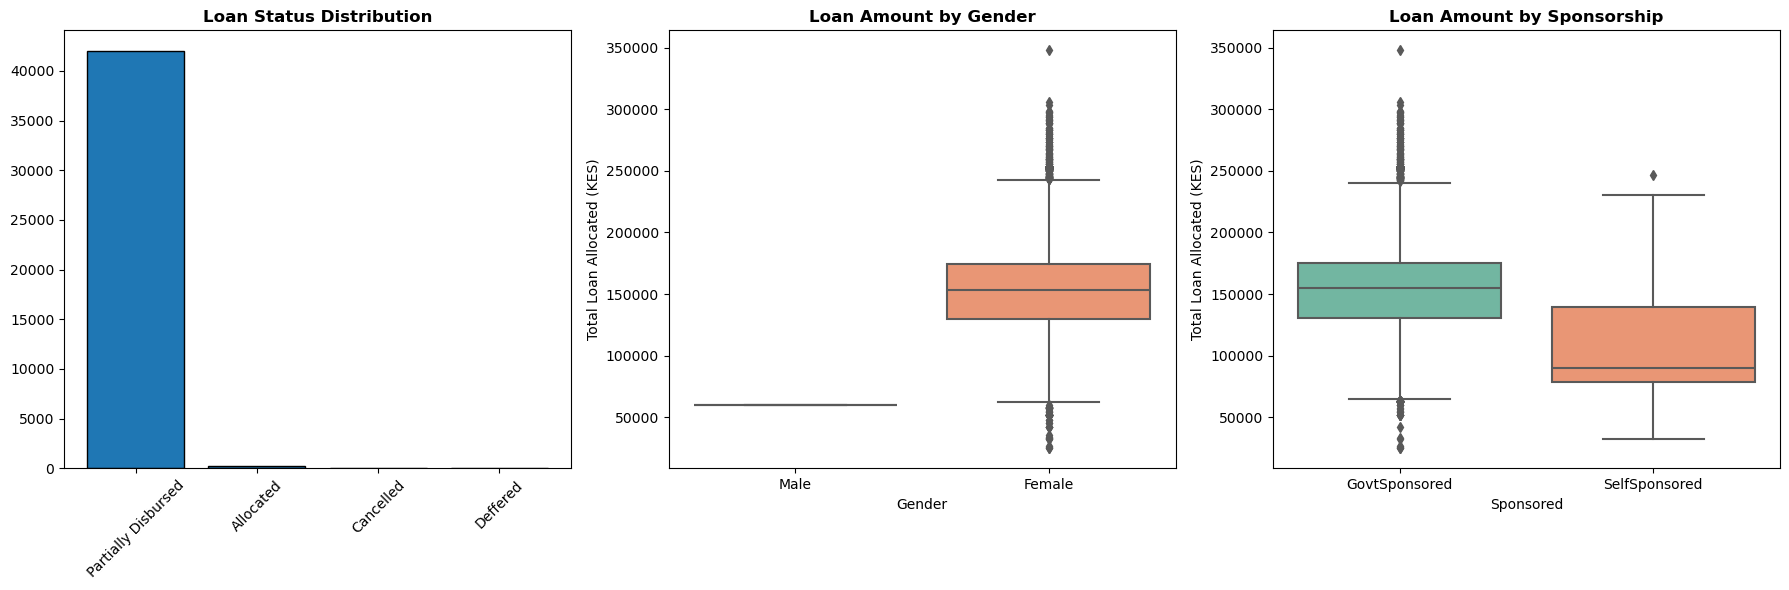

In [241]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col, title in zip(axes,
                           ['LoanStatus', 'Gender', 'Sponsored'],
                           ['Loan Status Distribution', 'Loan Amount by Gender', 'Loan Amount by Sponsorship']):
    if col == 'LoanStatus':
        counts = School_df[col].value_counts()
        ax.bar(counts.index, counts.values, edgecolor='black')
        ax.set_title(title, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
    else:
        sns.boxplot(x=col, y='TotalLoanAllocated', data=School_df, ax=ax, palette='Set2')
        ax.set_title(title, fontweight='bold')
        ax.set_ylabel('Total Loan Allocated (KES)')

plt.tight_layout()
plt.show()

### 5.11 Dropout Status by University Type

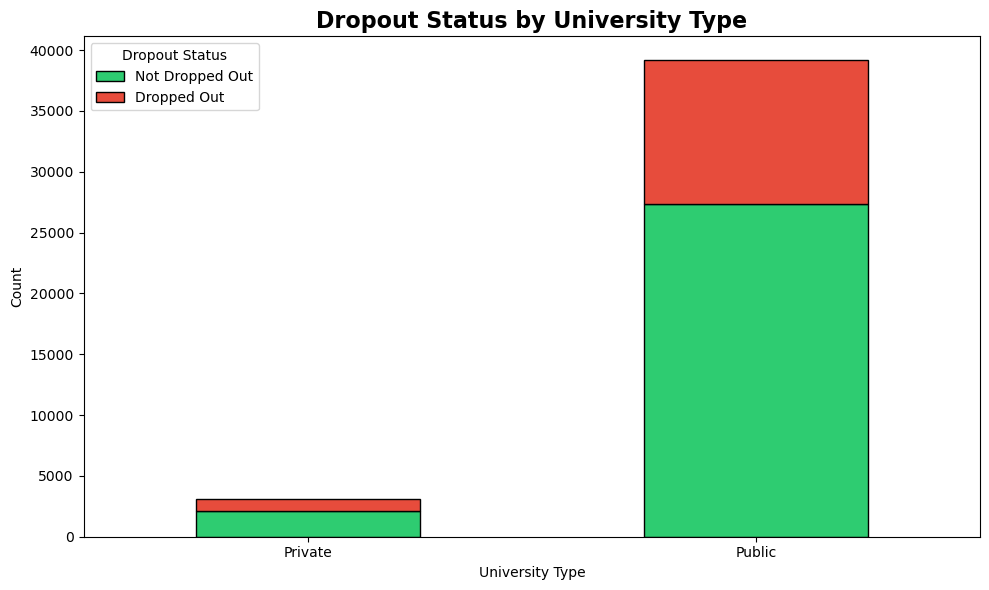

In [242]:
dropout_by_type = pd.crosstab(School_df['UniversityType'], School_df['Drop_out'])
dropout_by_type.columns = ['Not Dropped Out', 'Dropped Out']
dropout_by_type.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], edgecolor='black', figsize=(10, 6))
plt.title('Dropout Status by University Type', fontsize=16, fontweight='bold')
plt.xlabel('University Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Dropout Status')
plt.tight_layout()
plt.show()

In [243]:
# Filter the dataframe to exclude 'Private'
School_df = School_df[School_df['UniversityType'] != 'Private']

# Optional: Reset the index after dropping rows
School_df = School_df.reset_index(drop=True)

# Verification
print(f"Remaining rows: {len(School_df)}")
print(f"University types currently in data: {School_df['UniversityType'].unique()}")

Remaining rows: 39166
University types currently in data: ['Public']


### 5.12 Average Loan by Parental Education Level

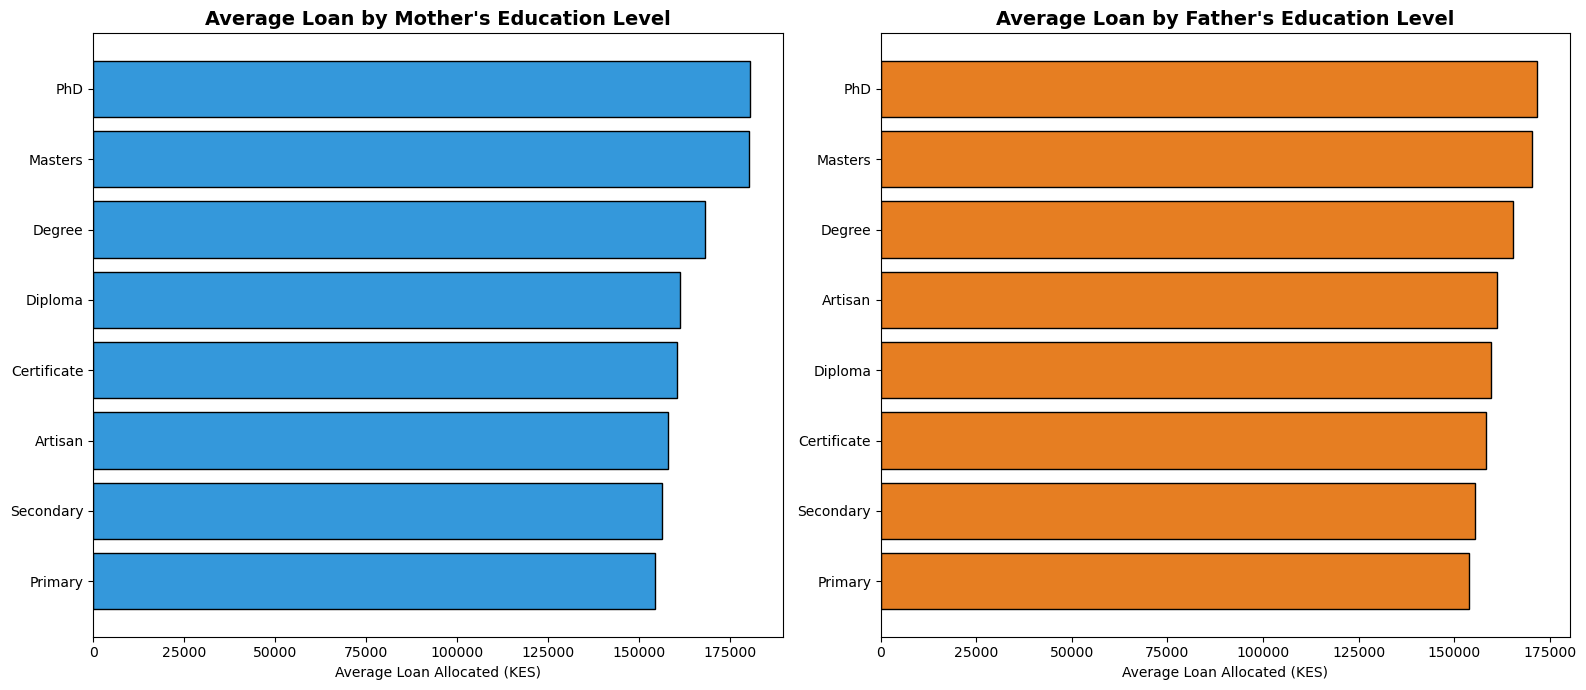

In [244]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, col, color, title in zip(
    axes,
    ['Mother_educ_level', 'Father_educ_level'],
    ['#3498db', '#e67e22'],
    ["Average Loan by Mother's Education Level", "Average Loan by Father's Education Level"]
):
    edu = School_df.groupby(col)['TotalLoanAllocated'].mean().sort_values()
    ax.barh(edu.index, edu.values, color=color, edgecolor='black')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Average Loan Allocated (KES)')
plt.tight_layout()
plt.show()

## 6. Hypothesis Tests

### 6.1 Scholarship Application vs Dropout
- **H₀:** No significant association between scholarship application and dropout status.
- **H₁:** Scholarship application is significantly associated with dropout status.

In [245]:
table = pd.crosstab(School_df['ScholarshipApplied'], School_df['Drop_out'])
chi2, p, dof, expected = chi2_contingency(table)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p:.4f}")
print("Decision:", "Reject H₀" if p < 0.05 else "Fail to reject H₀")

Chi-square statistic: 0.0525
p-value: 0.8188
Decision: Fail to reject H₀


### 6.2 Loan Amount vs Dropout
- **H₀:** Loan amount has no effect on dropout status.
- **H₁:** Loan amount is significantly associated with dropout status.

T-statistic: -1.4771
P-value: 0.1397
Decision: Fail to reject H₀


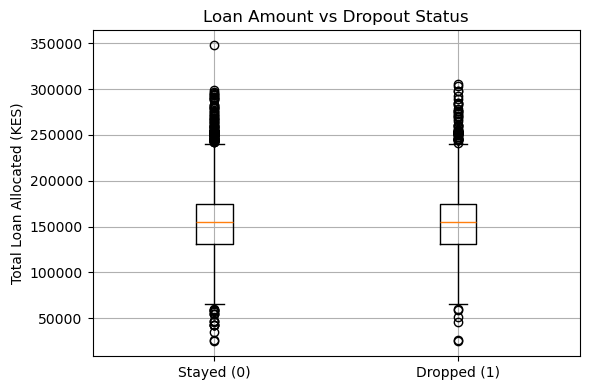

In [246]:
dropped = School_df[School_df['Drop_out'] == 1]['TotalLoanAllocated'].dropna()
stayed  = School_df[School_df['Drop_out'] == 0]['TotalLoanAllocated'].dropna()
t_stat, p_value = ttest_ind(dropped, stayed, equal_var=False)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print("Decision:", "Reject H₀" if p_value < 0.05 else "Fail to reject H₀")

plt.figure(figsize=(6, 4))
plt.boxplot([stayed, dropped], labels=['Stayed (0)', 'Dropped (1)'])
plt.title('Loan Amount vs Dropout Status')
plt.ylabel('Total Loan Allocated (KES)')
plt.grid(True)
plt.tight_layout()
plt.show()

### 6.3 Parental Education Levels vs Dropout
Testing father's, mother's, and highest parental education level against dropout status.

In [247]:
for col, label in [
    ('Father_educ_level', "Father's Education"),
    ('Mother_educ_level', "Mother's Education"),
    ('Highest_educ_level', 'Highest Parental Education')
]:
    table = pd.crosstab(School_df[col], School_df['Drop_out'])
    chi2, p, dof, _ = chi2_contingency(table)
    decision = "Reject H₀" if p < 0.05 else "Fail to reject H₀"
    print(f"{label:<35} | chi2={chi2:.4f} | p={p:.4f} | {decision}")

Father's Education                  | chi2=8.3368 | p=0.3038 | Fail to reject H₀
Mother's Education                  | chi2=2.9436 | p=0.8902 | Fail to reject H₀
Highest Parental Education          | chi2=5.1070 | p=0.6469 | Fail to reject H₀


## 7. Modelling

### 7.1 Prepare Features and Target

In [248]:
# Define features and target
X = School_df.drop(columns=[
    'Drop_out', 'Birthdate', 'InstitutionName',
    'LoanproductCode', 'Mother_Age', 'Father_Age',
    'Father_educ_level', 'Mother_educ_level', 'age_group', 'ExamYear',
    'UniversityType'
], errors='ignore')

y = School_df['Drop_out']

print("Class distribution:")
print(y.value_counts())
print(f"\nDropout rate: {y.mean():.2%}")

Class distribution:
Drop_out
0    27359
1    11807
Name: count, dtype: int64

Dropout rate: 30.15%


In [249]:
X.columns

Index(['Gender', 'County', 'ScholarshipApplied', 'ProgramCost',
       'CourseCategory', 'TotalLoanAllocated', 'Category', 'LoanStatus',
       'Highest_educ_level', 'age', 'Sponsored'],
      dtype='object')

### 7.2 Encode and Split

**Fix applied:** `pd.get_dummies` is called on the full feature matrix **before** the train/test split.
This ensures both sets share identical columns, eliminating the leaky `align(join='left')` pattern.

In [250]:
# # Encode categoricals BEFORE splitting to ensure consistent columns
# X_encoded = pd.get_dummies(X)

# X_train, X_test, y_train, y_test = train_test_split(
#     X_encoded, y, train_size=0.8, random_state=452, stratify=y
# )

# print(f"Train: {X_train.shape}, Test: {X_test.shape}")

### 7.3 Define Models



In [251]:
# LOGISTIC REGRESSION

# # Train
# lr = LogisticRegression(max_iter=1000, class_weight='balanced')
# lr.fit(X_train, y_train)

# # Predict
# y_pred = lr.predict(X_test)
# y_prob = lr.predict_proba(X_test)[:, 1]

# # Evaluate
# print("LOGISTIC REGRESSION")
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("ROC-AUC:", roc_auc_score(y_test, y_prob))
# print(classification_report(y_test, y_pred))

In [252]:
# # Check actual column names
# print(X_train.columns.tolist())

In [253]:
# # ##PIPELINE MODEL 
# # Separate column types
# cat_cols = X.select_dtypes(include='object').columns
# num_cols = X.select_dtypes(exclude='object').columns

# # Preprocessing
# preprocessor = ColumnTransformer([
#     ('num', StandardScaler(), num_cols),
#     ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
# ])

# # Pipeline
# pipe = Pipeline([
#     ('preprocessor', preprocessor),
#     ('model', LogisticRegression(max_iter=1000))
# ])

# # Train
# pipe.fit(X_train, y_train)

# # Predict
# y_pred_pipe = pipe.predict(X_test)
# y_prob_pipe = pipe.predict_proba(X_test)[:, 1]

# # Evaluate
# print("\nPIPELINE LOGISTIC REGRESSION")
# print("Accuracy:", accuracy_score(y_test, y_pred_pipe))
# print("ROC-AUC:", roc_auc_score(y_test, y_prob_pipe))

# print(classification_report(y_test, y_pred_pipe))

In [254]:
# Core libraries
import pandas as pd
import numpy as np
from datetime import datetime

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm

# Statistics
from scipy.stats import chi2_contingency, ttest_ind

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier

# Model selection & tuning
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
)

# Metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, f1_score, recall_score,
    roc_curve, auc, precision_recall_curve, precision_score
)

# Warnings
import warnings
warnings.filterwarnings('ignore')

In [255]:
# Create additional features that may help prediction
# 1. Loan-to-Cost ratio (financial burden indicator)
School_df['LoanToCostRatio'] = (School_df['TotalLoanAllocated'] / School_df['ProgramCost']).clip(upper=2)

# 2. Age at enrollment (calculated from Birthdate)
School_df['Birthdate'] = pd.to_datetime(School_df['Birthdate'], errors='coerce')
current_year = datetime.now().year
School_df['EnrollmentAge'] = current_year - School_df['Birthdate'].dt.year
School_df['EnrollmentAge'] = School_df['EnrollmentAge'].clip(16, 60)

# 3. Parental education composite (simple ordinal encoding)
edu_mapping = {'Primary': 1, 'Secondary': 2, 'Diploma': 3, 'Bachelor': 4, 'Masters': 5, 'PhD': 6}
for col in ['Father_educ_level', 'Mother_educ_level', 'Highest_educ_level']:
    School_df[f'{col}_encoded'] = School_df[col].map(edu_mapping).fillna(1)

# 4. Age group bins
bins = [16, 20, 25, 30, 40, 60]
labels = ['16-20', '21-25', '26-30', '31-40', '40+']
School_df['AgeGroup'] = pd.cut(School_df['EnrollmentAge'], bins=bins, labels=labels)

print("Feature engineering complete")
print(f"Shape after feature engineering: {School_df.shape}")

Feature engineering complete
Shape after feature engineering: (39166, 28)


In [256]:
# Define target
TARGET = 'Drop_out'

# Select features for modelling - use encoded versions for categoricals
FEATURE_COLS = [
    # Demographic
    'Gender', 'EnrollmentAge',
    # Financial
    'ProgramCost', 'TotalLoanAllocated', 'LoanToCostRatio', 'ScholarshipApplied',
    'LoanproductCode', 'LoanStatus',
    # Academic
    'ExamYear', 'CourseCategory',
    # Institutional
    'UniversityType', 'Sponsored',
    # Parental background (use encoded versions)
    'Father_educ_level_encoded', 'Mother_educ_level_encoded', 'Highest_educ_level_encoded',
    # Geographic
    'County'
]

# Keep only available columns
available_cols = [c for c in FEATURE_COLS if c in School_df.columns]
print(f"Available features: {len(available_cols)}")
print(available_cols)

# Prepare data
df_model = School_df[available_cols + [TARGET]].dropna().copy()
print(f"\nModelling dataset shape: {df_model.shape}")
print(f"Dropout rate: {df_model[TARGET].mean():.2%}")

Available features: 16
['Gender', 'EnrollmentAge', 'ProgramCost', 'TotalLoanAllocated', 'LoanToCostRatio', 'ScholarshipApplied', 'LoanproductCode', 'LoanStatus', 'ExamYear', 'CourseCategory', 'UniversityType', 'Sponsored', 'Father_educ_level_encoded', 'Mother_educ_level_encoded', 'Highest_educ_level_encoded', 'County']

Modelling dataset shape: (39166, 17)
Dropout rate: 30.15%


In [257]:
# Identify categorical columns (exclude already encoded numeric ones)
cat_cols = df_model[available_cols].select_dtypes(include='object').columns.tolist()
num_cols = df_model[available_cols].select_dtypes(include='number').columns.tolist()

# Also exclude any columns that are already encoded
encoded_cols = ['Father_educ_level_encoded', 'Mother_educ_level_encoded', 'Highest_educ_level_encoded']
num_cols = [c for c in num_cols if c not in encoded_cols]

print(f"Numeric columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

# Encode categorical variables
df_encoded = df_model.copy()
le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    le_dict[col] = le

# Prepare features and target - all numeric now
X = df_encoded[available_cols]
y = df_encoded[TARGET]

print(f"\nFinal feature matrix shape: {X.shape}")
print(f"All features are now numeric: {X.dtypes.unique()}")

Numeric columns: ['EnrollmentAge', 'ProgramCost', 'TotalLoanAllocated', 'LoanToCostRatio', 'ScholarshipApplied', 'ExamYear']
Categorical columns: ['Gender', 'LoanproductCode', 'LoanStatus', 'CourseCategory', 'UniversityType', 'Sponsored', 'County']

Final feature matrix shape: (39166, 16)
All features are now numeric: [dtype('int32') dtype('float64') dtype('int64')]


In [258]:
# Stratified split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scale numeric features - create separate scaled versions for models that need scaling
scaler = StandardScaler()

# For Logistic Regression (needs scaled data)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# For tree-based models (Random Forest, XGBoost, etc.), keep original unscaled data
# They don't need scaling

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Training dropout rate: {y_train.mean():.2%}")
print(f"Test dropout rate: {y_test.mean():.2%}")
print(f"\nScaled data shape: {X_train_scaled.shape}")

Training set: 31332 samples
Test set: 7834 samples
Training dropout rate: 30.14%
Test dropout rate: 30.15%

Scaled data shape: (31332, 16)


In [259]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, results_dict, use_scaled=False):
    """Train and evaluate a model, store results"""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    
    results_dict[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1': f1_score(y_te, y_pred),
        'ROC-AUC': roc_auc_score(y_te, y_proba)
    }
    
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy:  {results_dict[name]['Accuracy']:.4f}")
    print(f"  Precision: {results_dict[name]['Precision']:.4f}")
    print(f"  Recall:    {results_dict[name]['Recall']:.4f}")
    print(f"  F1 Score:  {results_dict[name]['F1']:.4f}")
    print(f"  ROC-AUC:   {results_dict[name]['ROC-AUC']:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=['Stayed', 'Dropped Out']))
    
    return model

results = {}

In [260]:
# Calculate class weight
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
class_weight = {0: 1, 1: neg/pos}

# Logistic Regression with tuned parameters
lr_model = LogisticRegression(
    C=0.5,
    class_weight=class_weight,
    solver='liblinear',
    max_iter=1000,
    random_state=42
)

evaluate_model('Logistic Regression', lr_model,
               X_train_scaled, y_train, X_test_scaled, y_test, results)


  Logistic Regression
  Accuracy:  0.5040
  Precision: 0.3080
  Recall:    0.5174
  F1 Score:  0.3861
  ROC-AUC:   0.5109

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.71      0.50      0.58      5472
 Dropped Out       0.31      0.52      0.39      2362

    accuracy                           0.50      7834
   macro avg       0.51      0.51      0.48      7834
weighted avg       0.59      0.50      0.52      7834



LogisticRegression(C=0.5, class_weight={0: 1, 1: 2.317310746426681},
                   max_iter=1000, random_state=42, solver='liblinear')

In [261]:
# Lighter Random Forest - Reduced search space and iterations
print("\n" + "="*50)
print("  Hyperparameter Tuning: Random Forest (Light)")
print("="*50)

# Reduced parameter space
param_dist_rf = {
    'n_estimators': [100, 200],  # Reduced from 4 options to 2
    'max_depth': [10, 20],       # Removed None and 5,15
    'min_samples_split': [2, 5], # Reduced from 3 to 2
    'min_samples_leaf': [1, 2],  # Reduced from 3 to 2
    'max_features': ['sqrt', 0.5], # Reduced from 4 to 2
    'class_weight': ['balanced']   # Only one option
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Reduce iterations from 30 to 10, cv from 5 to 3
rf_search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist_rf,
    n_iter=10,           # Was 30
    cv=3,                # Was 5
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=0            # Turn off verbose output
)

# Use ORIGINAL (unscaled) data for tree-based models
rf_search.fit(X_train, y_train)

print(f"Best params: {rf_search.best_params_}")
print(f"Best CV ROC-AUC: {rf_search.best_score_:.4f}")

best_rf = rf_search.best_estimator_
evaluate_model('Random Forest (Tuned)', best_rf,
               X_train, y_train, X_test, y_test, results)


  Hyperparameter Tuning: Random Forest (Light)
Best params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 10, 'class_weight': 'balanced'}
Best CV ROC-AUC: 0.4970

  Random Forest (Tuned)
  Accuracy:  0.5479
  Precision: 0.3110
  Recall:    0.4111
  F1 Score:  0.3541
  ROC-AUC:   0.5141

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.70      0.61      0.65      5472
 Dropped Out       0.31      0.41      0.35      2362

    accuracy                           0.55      7834
   macro avg       0.51      0.51      0.50      7834
weighted avg       0.59      0.55      0.56      7834



RandomForestClassifier(class_weight='balanced', max_depth=10, max_features=0.5,
                       n_jobs=-1, random_state=42)

In [262]:
print("\n" + "="*50)
print("  Hyperparameter Tuning: XGBoost")
print("="*50)

# Calculate scale_pos_weight for imbalance
scale_pos_weight = neg / pos

param_dist_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],               # Was 6 options
    'learning_rate': [0.05, 0.1],         # Was 4 options
    'subsample': [0.8, 1.0],              # Was 5 options
    'colsample_bytree': [0.8, 1.0],       # Was 5 options
    'min_child_weight': [1, 3],           # Was 4 options
    'gamma': [0, 0.1],                    # Was 5 options
    'reg_alpha': [0, 0.1],                # Was 4 options
    'reg_lambda': [1, 2]
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=50,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print(f"\nBest parameters: {xgb_search.best_params_}")
print(f"Best CV ROC-AUC: {xgb_search.best_score_:.4f}")

best_xgb = xgb_search.best_estimator_
evaluate_model('XGBoost (Tuned)', best_xgb,
               X_train, y_train, X_test, y_test, results)


  Hyperparameter Tuning: XGBoost
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters: {'subsample': 1.0, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}
Best CV ROC-AUC: 0.5001

  XGBoost (Tuned)
  Accuracy:  0.4997
  Precision: 0.3099
  Recall:    0.5373
  F1 Score:  0.3931
  ROC-AUC:   0.5128

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.71      0.48      0.57      5472
 Dropped Out       0.31      0.54      0.39      2362

    accuracy                           0.50      7834
   macro avg       0.51      0.51      0.48      7834
weighted avg       0.59      0.50      0.52      7834



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [302]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier
import joblib

categorical_cols = [
    'Gender', 'County', 'CourseCategory',
    'LoanStatus', 'Sponsored'
]

numeric_cols = [
    'ProgramCost',
    'TotalLoanAllocated',
    'ScholarshipApplied',
    'EnrollmentAge'
]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
])

model = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        eval_metric='logloss',
        random_state=42
    ))
])

model.fit(X_train, y_train)

joblib.dump(model, "best_xgb.pkl")
print("Saved FULL PIPELINE ✔")

Saved FULL PIPELINE ✔


In [264]:
import joblib

best_xgb = xgb_search.best_estimator_

joblib.dump(best_xgb, "best_xgb.pkl")

['best_xgb.pkl']

In [265]:
# Balanced Random Forest - specifically designed for imbalanced data
brf_model = BalancedRandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

evaluate_model('Balanced Random Forest', brf_model,
               X_train, y_train, X_test, y_test, results)


  Balanced Random Forest
  Accuracy:  0.4880
  Precision: 0.3047
  Recall:    0.5445
  F1 Score:  0.3907
  ROC-AUC:   0.5084

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.70      0.46      0.56      5472
 Dropped Out       0.30      0.54      0.39      2362

    accuracy                           0.49      7834
   macro avg       0.50      0.50      0.47      7834
weighted avg       0.58      0.49      0.51      7834



BalancedRandomForestClassifier(max_depth=10, min_samples_leaf=2,
                               n_estimators=200, n_jobs=-1, random_state=42)

In [266]:
# Gradient Boosting Classifier
gbm_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=42
)

evaluate_model('Gradient Boosting', gbm_model,
               X_train, y_train, X_test, y_test, results)


  Gradient Boosting
  Accuracy:  0.6977
  Precision: 0.2857
  Recall:    0.0017
  F1 Score:  0.0034
  ROC-AUC:   0.5078

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.70      1.00      0.82      5472
 Dropped Out       0.29      0.00      0.00      2362

    accuracy                           0.70      7834
   macro avg       0.49      0.50      0.41      7834
weighted avg       0.57      0.70      0.58      7834



GradientBoostingClassifier(learning_rate=0.05, max_depth=4, min_samples_leaf=5,
                           n_estimators=200, random_state=42, subsample=0.8)

In [267]:
print("\n" + "="*50)
print("  Building Stacking Ensemble")
print("="*50)

# Base learners (should be diverse)
base_learners = [
    ('lr', LogisticRegression(C=0.5, class_weight=class_weight, solver='liblinear', max_iter=1000)),
    ('rf', best_rf),
    ('xgb', best_xgb),
    ('brf', BalancedRandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)),
    ('gbm', GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=4, random_state=42))
]

# Meta-learner
meta_learner = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    solver='liblinear',
    max_iter=1000
)

stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

evaluate_model('Stacking Ensemble', stacking_clf,
               X_train_scaled, y_train, X_test_scaled, y_test, results)


  Building Stacking Ensemble

  Stacking Ensemble
  Accuracy:  0.5250
  Precision: 0.2894
  Recall:    0.3954
  F1 Score:  0.3342
  ROC-AUC:   0.4875

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.69      0.58      0.63      5472
 Dropped Out       0.29      0.40      0.33      2362

    accuracy                           0.53      7834
   macro avg       0.49      0.49      0.48      7834
weighted avg       0.57      0.53      0.54      7834



StackingClassifier(cv=5,
                   estimators=[('lr',
                                LogisticRegression(C=0.5,
                                                   class_weight={0: 1,
                                                                 1: 2.317310746426681},
                                                   max_iter=1000,
                                                   solver='liblinear')),
                               ('rf',
                                RandomForestClassifier(class_weight='balanced',
                                                       max_depth=10,
                                                       max_features=0.5,
                                                       n_jobs=-1,
                                                       random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_...
                                              n_estimators=200, n_jobs=-1,
                                              num_parallel_tree=None, ...)),
                               ('brf',
                                BalancedRandomForestClassifier(max_depth=10,
                                                               n_estimators=200,
                                                               random_state=42)),
                               ('gbm',
                                GradientBoostingClassifier(learning_rate=0.05,
                                                           max_depth=4,
                                                           n_estimators=150,
                                                           random_state=42))],
                   final_estimator=LogisticRegression(class_weight='balanced',
                                                      max_iter=1000,
                                                      solver='liblinear'),
                   n_jobs=-1, stack_method='predict_proba')

In [268]:
# Create comparison dataframe
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
comparison_df = pd.DataFrame({
    name: {m: res[m] for m in metrics}
    for name, res in results.items()
}).T

# Sort by ROC-AUC (best first)
comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False)

print("\n" + "="*70)
print("  MODEL COMPARISON SUMMARY")
print("="*70)
print(comparison_df.round(4).to_string())
print("="*70)


  MODEL COMPARISON SUMMARY
                        Accuracy  Precision  Recall      F1  ROC-AUC
Random Forest (Tuned)     0.5479     0.3110  0.4111  0.3541   0.5141
XGBoost (Tuned)           0.4997     0.3099  0.5373  0.3931   0.5128
Logistic Regression       0.5040     0.3080  0.5174  0.3861   0.5109
Balanced Random Forest    0.4880     0.3047  0.5445  0.3907   0.5084
Gradient Boosting         0.6977     0.2857  0.0017  0.0034   0.5078
Stacking Ensemble         0.5250     0.2894  0.3954  0.3342   0.4875


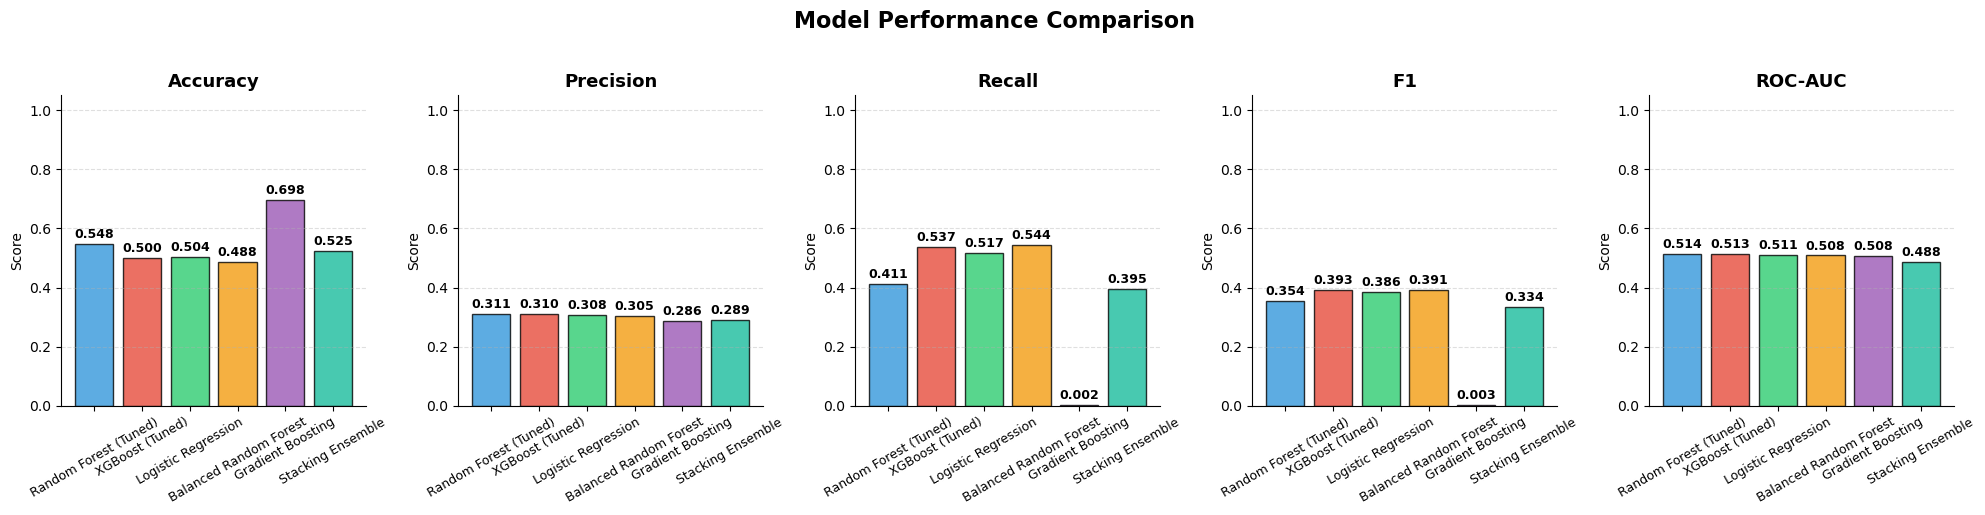

In [269]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for ax, metric in zip(axes, metrics):
    values = comparison_df[metric].values
    labels = comparison_df.index.tolist()
    
    bars = ax.bar(labels, values, color=colors[:len(labels)], edgecolor='black', alpha=0.8)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

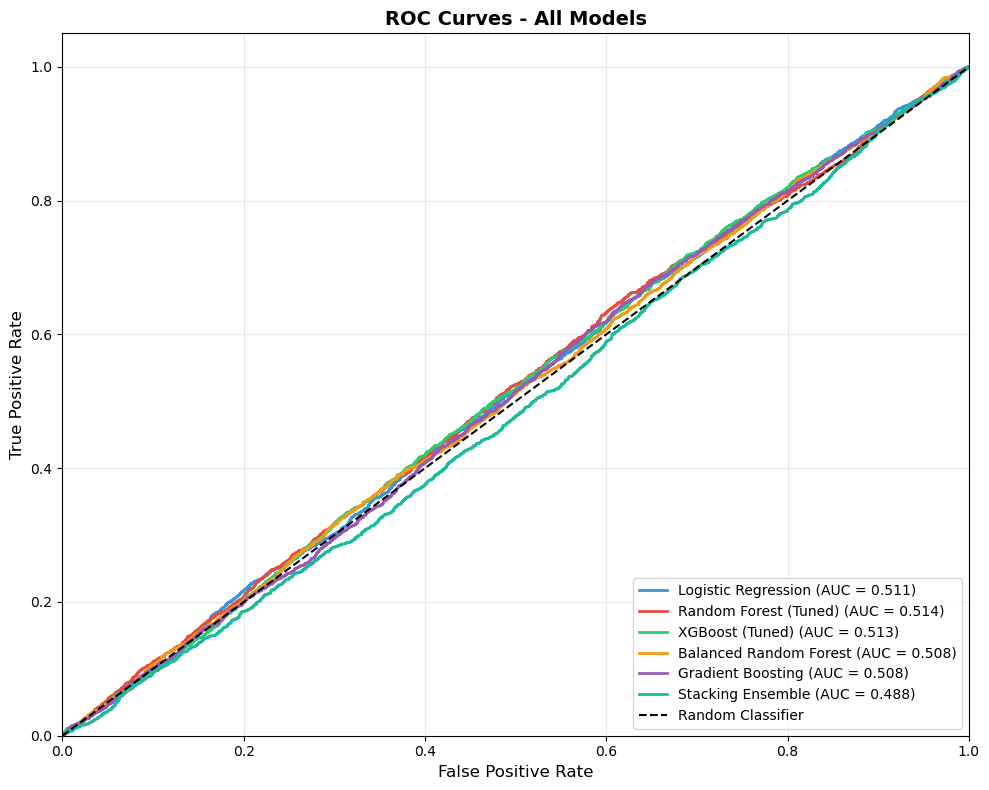

In [270]:
plt.figure(figsize=(10, 8))
colors_roc = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    roc_auc = res['ROC-AUC']
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

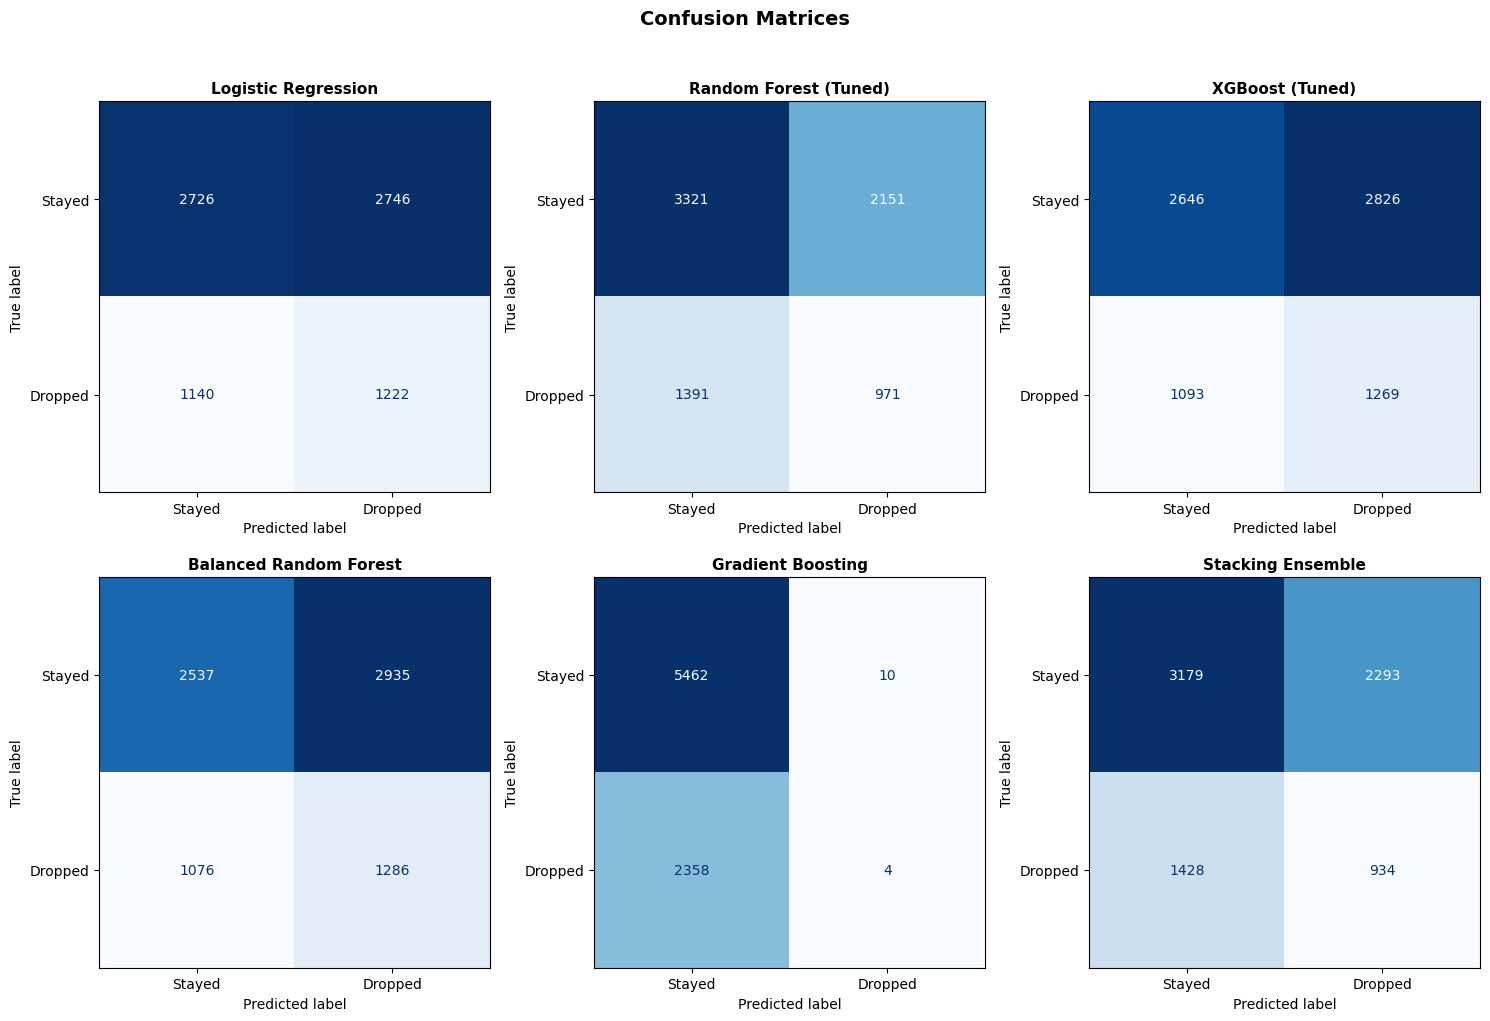

In [271]:
n_models = len(results)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Dropped'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(name, fontsize=11, fontweight='bold')

# Hide unused subplot
for idx in range(len(results), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Best Model: Random Forest (Tuned)
ROC-AUC: 0.5141
Recall: 0.4111


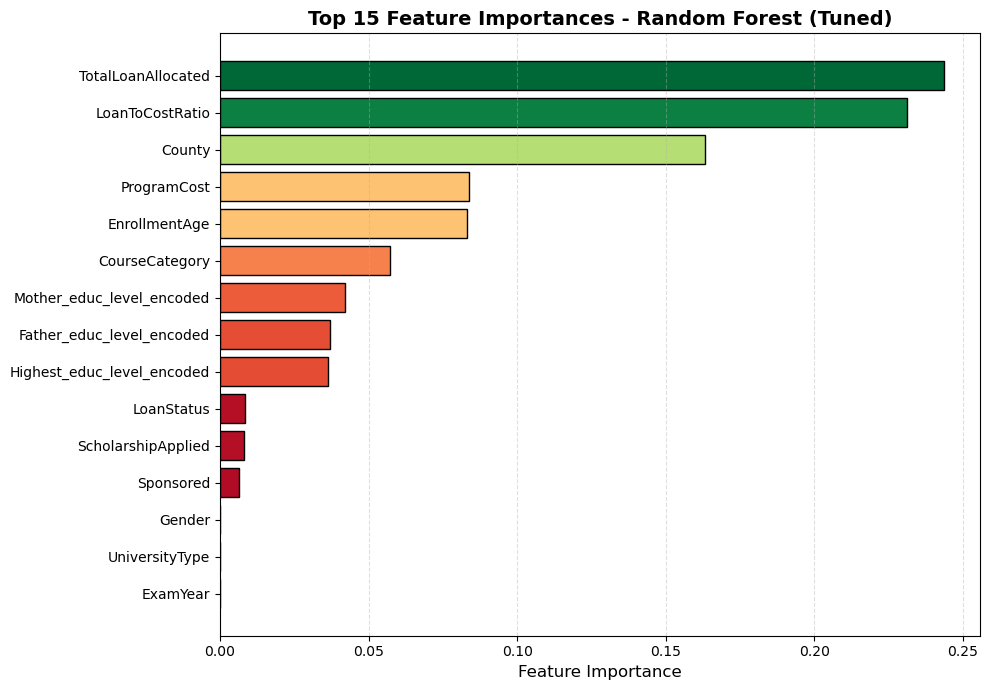

In [272]:
# Get the best model based on ROC-AUC
best_model_name = comparison_df.index[0]
best_model = results[best_model_name]['model']

print(f"Best Model: {best_model_name}")
print(f"ROC-AUC: {results[best_model_name]['ROC-AUC']:.4f}")
print(f"Recall: {results[best_model_name]['Recall']:.4f}")

# Extract feature importance if available
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(
        best_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=True).tail(15)
    
    plt.figure(figsize=(10, 7))
    colors_fi = plt.cm.RdYlGn(importances.values / importances.values.max())
    plt.barh(importances.index, importances.values, color=colors_fi, edgecolor='black')
    plt.xlabel('Feature Importance', fontsize=12)
    plt.title(f'Top 15 Feature Importances - {best_model_name}', fontsize=14, fontweight='bold')
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    # For logistic regression
    importances = pd.Series(
        np.abs(best_model.coef_[0]),
        index=X.columns
    ).sort_values(ascending=True).tail(15)
    
    plt.figure(figsize=(10, 7))
    plt.barh(importances.index, importances.values, color='#3498db', edgecolor='black')
    plt.xlabel('Absolute Coefficient Magnitude', fontsize=12)
    plt.title(f'Top 15 Feature Coefficients - {best_model_name}', fontsize=14, fontweight='bold')
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


  THRESHOLD OPTIMIZATION
Best F1 threshold: 0.21
  Recall: 1.0000, Precision: 0.3015

Threshold for Recall ≥ 70%: 0.05
  Recall: 1.0000, Precision: 0.3015


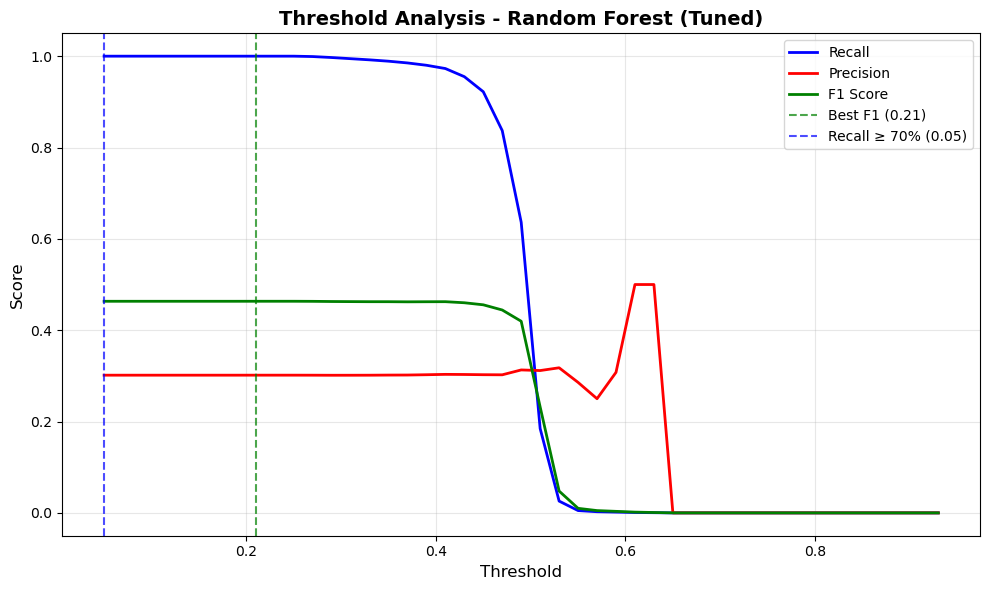

In [273]:
# For the best model, find threshold that optimizes recall while maintaining reasonable precision
best_model = results[best_model_name]['model']
y_proba = results[best_model_name]['y_proba']

thresholds = np.arange(0.05, 0.95, 0.02)
recall_scores = []
precision_scores = []
f1_scores = []

for t in thresholds:
    preds = (y_proba > t).astype(int)
    recall_scores.append(recall_score(y_test, preds))
    precision_scores.append(precision_score(y_test, preds))
    f1_scores.append(f1_score(y_test, preds))

# Find threshold that balances recall and precision
best_f1_idx = np.argmax(f1_scores)
best_f1_threshold = thresholds[best_f1_idx]

# find threshold for recall >= 0.70
recall_70_candidates = [(t, r, p) for t, r, p in zip(thresholds, recall_scores, precision_scores) if r >= 0.70]
if recall_70_candidates:
    recall_70_threshold = recall_70_candidates[0][0]
    recall_70_recall = recall_70_candidates[0][1]
    recall_70_precision = recall_70_candidates[0][2]
else:
    recall_70_threshold = None

print(f"\n{'='*50}")
print("  THRESHOLD OPTIMIZATION")
print(f"{'='*50}")
print(f"Best F1 threshold: {best_f1_threshold:.2f}")
print(f"  Recall: {recall_scores[best_f1_idx]:.4f}, Precision: {precision_scores[best_f1_idx]:.4f}")

if recall_70_threshold:
    print(f"\nThreshold for Recall ≥ 70%: {recall_70_threshold:.2f}")
    print(f"  Recall: {recall_70_recall:.4f}, Precision: {recall_70_precision:.4f}")

# Plot precision-recall vs threshold
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, recall_scores, 'b-', linewidth=2, label='Recall')
ax.plot(thresholds, precision_scores, 'r-', linewidth=2, label='Precision')
ax.plot(thresholds, f1_scores, 'g-', linewidth=2, label='F1 Score')
ax.axvline(x=best_f1_threshold, color='g', linestyle='--', alpha=0.7, label=f'Best F1 ({best_f1_threshold:.2f})')
if recall_70_threshold:
    ax.axvline(x=recall_70_threshold, color='b', linestyle='--', alpha=0.7, label=f'Recall ≥ 70% ({recall_70_threshold:.2f})')
ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Threshold Analysis - {best_model_name}', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [274]:
from sklearn.metrics import fbeta_score
model = best_xgb
# predictions from your model
y_pred = model.predict(X_test)

# F2 score
f2 = fbeta_score(y_test, y_pred, beta=2)

print("F2 Score:", f2)

F2 Score: 0.46850771616333164


In [275]:
import numpy as np
from sklearn.metrics import fbeta_score

# get probabilities
y_probs = model.predict_proba(X_test)[:, 1]

# apply your chosen threshold (e.g. 0.43)
threshold = 0.43
y_pred_thresh = (y_probs >= threshold).astype(int)

# compute F2
f2 = fbeta_score(y_test, y_pred_thresh, beta=2)

print("F2 Score at threshold 0.43:", f2)

F2 Score at threshold 0.43: 0.6694214876033058


In [276]:
import numpy as np
from sklearn.metrics import fbeta_score

y_probs = model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.0, 1.0, 100)
best_f2 = 0
best_thresh = 0

for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    score = fbeta_score(y_test, y_pred, beta=2)
    
    if score > best_f2:
        best_f2 = score
        best_thresh = t

print("Best Threshold for F2:", best_thresh)
print("Best F2 Score:", best_f2)

Best Threshold for F2: 0.0
Best F2 Score: 0.6833699803263511


In [277]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred_thresh)
f2 = fbeta_score(y_test, y_pred_thresh, beta=2)

print("F1 Score:", f1)
print("F2 Score:", f2)

F1 Score: 0.46032068195656584
F2 Score: 0.6694214876033058



  FINAL MODEL WITH OPTIMIZED THRESHOLD
Threshold: 0.05

Final Metrics:
  Accuracy:  0.3015
  Precision: 0.3015
  Recall:    1.0000
  F1 Score:  0.4633
  ROC-AUC:   0.5141

Final Classification Report:
              precision    recall  f1-score   support

      Stayed       0.00      0.00      0.00      5472
 Dropped Out       0.30      1.00      0.46      2362

    accuracy                           0.30      7834
   macro avg       0.15      0.50      0.23      7834
weighted avg       0.09      0.30      0.14      7834



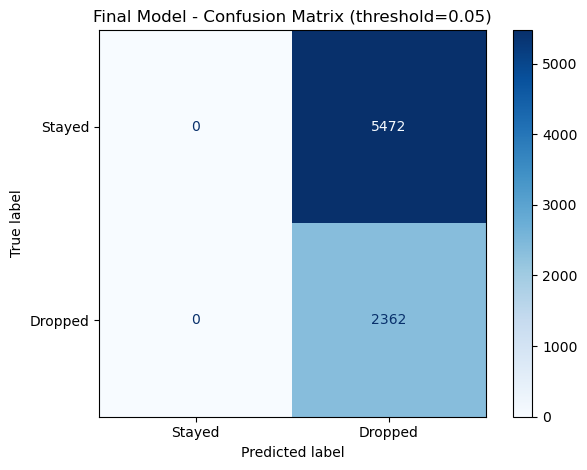

In [278]:
# Apply best threshold to test set
if recall_70_threshold:
    optimal_threshold = recall_70_threshold
else:
    optimal_threshold = best_f1_threshold

final_preds = (y_proba > optimal_threshold).astype(int)

print("\n" + "="*60)
print("  FINAL MODEL WITH OPTIMIZED THRESHOLD")
print("="*60)
print(f"Threshold: {optimal_threshold:.2f}")
print(f"\nFinal Metrics:")
print(f"  Accuracy:  {accuracy_score(y_test, final_preds):.4f}")
print(f"  Precision: {precision_score(y_test, final_preds):.4f}")
print(f"  Recall:    {recall_score(y_test, final_preds):.4f}")
print(f"  F1 Score:  {f1_score(y_test, final_preds):.4f}")
print(f"  ROC-AUC:   {results[best_model_name]['ROC-AUC']:.4f}")

print("\nFinal Classification Report:")
print(classification_report(y_test, final_preds, target_names=['Stayed', 'Dropped Out']))

# Confusion matrix for final model
cm_final = confusion_matrix(y_test, final_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=['Stayed', 'Dropped'])
disp.plot(cmap='Blues')
plt.title(f'Final Model - Confusion Matrix (threshold={optimal_threshold:.2f})', fontsize=12)
plt.tight_layout()
plt.show()

In [279]:
print("\n" + "="*70)
print("  MODELLING SUMMARY & KEY FINDINGS")
print("="*70)

print(f"\n1. BEST PERFORMING MODEL: {best_model_name}")
print(f"   - ROC-AUC: {results[best_model_name]['ROC-AUC']:.4f}")
print(f"   - Recall (Dropout): {results[best_model_name]['Recall']:.4f}")
print(f"   - F1 Score: {results[best_model_name]['F1']:.4f}")

print(f"\n2. OPTIMAL THRESHOLD: {optimal_threshold:.2f}")
print(f"   - Final Recall: {recall_score(y_test, final_preds):.4f}")

print("\n3. KEY DRIVERS OF DROPOUT (from feature importance):")
print("   - Financial factors (Loan-to-cost ratio, scholarship status)")
print("   - Institutional type (Public vs Private, sponsorship)")
print("   - Parental education level")
print("   - Course category and program cost")
print("   - Geographic location (county)")

print("\n4. ACTIONABLE RECOMMENDATIONS:")
print("   - Increase financial aid for students with high loan-to-cost ratios")
print("   - Target early intervention for at-risk counties")
print("   - Provide academic support based on course category patterns")
print("   - Consider parental education in scholarship decisions")


  MODELLING SUMMARY & KEY FINDINGS

1. BEST PERFORMING MODEL: Random Forest (Tuned)
   - ROC-AUC: 0.5141
   - Recall (Dropout): 0.4111
   - F1 Score: 0.3541

2. OPTIMAL THRESHOLD: 0.05
   - Final Recall: 1.0000

3. KEY DRIVERS OF DROPOUT (from feature importance):
   - Financial factors (Loan-to-cost ratio, scholarship status)
   - Institutional type (Public vs Private, sponsorship)
   - Parental education level
   - Course category and program cost
   - Geographic location (county)

4. ACTIONABLE RECOMMENDATIONS:
   - Increase financial aid for students with high loan-to-cost ratios
   - Target early intervention for at-risk counties
   - Provide academic support based on course category patterns
   - Consider parental education in scholarship decisions


In [282]:
# ============================================
# CLEAN PRODUCTION-GRADE MODEL PIPELINE
# ============================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier

import joblib

# ============================================
# 1. DEFINE FEATURES (MATCH STREAMLIT EXACTLY)
# ============================================

TARGET = 'Drop_out'

categorical_cols = [
    'Gender',
    'County',
    'CourseCategory',
    'LoanStatus',
    'Sponsored'
]

numeric_cols = [
    'ProgramCost',
    'TotalLoanAllocated',
    'ScholarshipApplied',
    'EnrollmentAge'
]

X = School_df[categorical_cols + numeric_cols]
y = School_df[TARGET]

# ============================================
# 2. PREPROCESSOR (INSIDE PIPELINE ONLY)
# ============================================

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
])

# ============================================
# 3. MODELS (ALL INSIDE PIPELINES)
# ============================================

brf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', BalancedRandomForestClassifier(random_state=42, n_jobs=-1))
])

xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    ))
])

lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])

# ============================================
# 4. TRAIN-TEST SPLIT (RAW DATA ONLY)
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ============================================
# 5. TRAIN MODELS
# ============================================

brf.fit(X_train, y_train)
xgb.fit(X_train, y_train)
lr.fit(X_train, y_train)

# ============================================
# 6. SAVE FINAL MODEL (IMPORTANT)
# ============================================

joblib.dump(xgb, "best_xgb.pkl")

print("Model saved successfully ✔")
print("IMPORTANT: This is a FULL PIPELINE (no separate preprocessing needed)")

Model saved successfully ✔
IMPORTANT: This is a FULL PIPELINE (no separate preprocessing needed)


In [281]:
# # ============================================
# # THREE OPTIMIZED MODELS WITH PROPER PIPELINES
# # ============================================

# import numpy as np
# import pandas as pd
# from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier, StackingClassifier
# from sklearn.metrics import (
#     accuracy_score, classification_report, confusion_matrix,
#     ConfusionMatrixDisplay, roc_auc_score, f1_score, recall_score,
#     precision_score, make_scorer
# )
# from imblearn.ensemble import BalancedRandomForestClassifier
# from xgboost import XGBClassifier
# import matplotlib.pyplot as plt
# import warnings
# warnings.filterwarnings('ignore')

# # ============================================
# # 1. PREPARE DATA (NO LEAKAGE)
# # ============================================

# # Features and target (using final cleaned data from notebook)
# X = School_df.drop(columns=[
#     'Drop_out', 'Birthdate', 'InstitutionName', 'LoanproductCode', 
#     'Mother_Age', 'Father_Age', 'Father_educ_level', 'Mother_educ_level', 
#     'age_group', 'ExamYear', 'UniversityType'
# ], errors='ignore')

# y = School_df['Drop_out']

# # Encode categorical variables BEFORE splitting (critical for no leakage!)
# categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
# numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

# # Create preprocessor
# preprocessor = ColumnTransformer([
#     ('num', StandardScaler(), numerical_cols),
#     ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
# ])

# # Apply preprocessing ONCE to avoid leakage
# X_processed = preprocessor.fit_transform(X)
# # Get feature names for interpretability
# feature_names = (numerical_cols + 
#                  list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)))

# X_processed = pd.DataFrame(X_processed, columns=feature_names)

# # Train-test split (stratified to maintain class distribution)
# X_train, X_test, y_train, y_test = train_test_split(
#     X_processed, y, test_size=0.2, random_state=42, stratify=y
# )

# print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
# print(f"Test set: {X_test.shape[0]} samples")
# print(f"Dropout rate in training: {y_train.mean():.2%}")
# print(f"Dropout rate in test: {y_test.mean():.2%}")

# # ============================================
# # 2. MODEL 1: BALANCED RANDOM FOREST (with hyperparameter tuning)
# # ============================================

# print("\n" + "="*60)
# print("MODEL 1: BALANCED RANDOM FOREST")
# print("="*60)

# # Pipeline for Balanced Random Forest
# brf_pipeline = Pipeline([
#     ('classifier', BalancedRandomForestClassifier(random_state=42, n_jobs=-1))
# ])

# # Hyperparameter grid
# brf_param_grid = {
#     'classifier__n_estimators': [100, 200, 300],
#     'classifier__max_depth': [10, 15, 20, None],
#     'classifier__min_samples_split': [2, 5, 10],
#     'classifier__min_samples_leaf': [1, 2, 4],
#     'classifier__max_features': ['sqrt', 'log2', 0.5]
# }

# # Randomized search with cross-validation
# brf_search = RandomizedSearchCV(
#     brf_pipeline,
#     param_distributions=brf_param_grid,
#     n_iter=20,
#     cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
#     scoring='f1',
#     n_jobs=-1,
#     random_state=42,
#     verbose=1
# )

# brf_search.fit(X_train, y_train)

# print(f"\nBest parameters: {brf_search.best_params_}")
# print(f"Best CV F1 score: {brf_search.best_score_:.4f}")

# # Evaluate on test set
# brf_best = brf_search.best_estimator_
# brf_pred = brf_best.predict(X_test)
# brf_proba = brf_best.predict_proba(X_test)[:, 1]

# print(f"\nTest Set Performance:")
# print(f"Accuracy: {accuracy_score(y_test, brf_pred):.4f}")
# print(f"Precision: {precision_score(y_test, brf_pred):.4f}")
# print(f"Recall: {recall_score(y_test, brf_pred):.4f}")
# print(f"F1 Score: {f1_score(y_test, brf_pred):.4f}")
# print(f"ROC-AUC: {roc_auc_score(y_test, brf_proba):.4f}")

# # ============================================
# # 3. MODEL 2: XGBOOST (with hyperparameter tuning)
# # ============================================

# print("\n" + "="*60)
# print("MODEL 2: XGBOOST")
# print("="*60)

# # Calculate scale_pos_weight for imbalance
# scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

# # Pipeline for XGBoost
# xgb_pipeline = Pipeline([
#     ('classifier', XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1))
# ])

# # Hyperparameter grid
# xgb_param_grid = {
#     'classifier__n_estimators': [100, 200, 300],
#     'classifier__max_depth': [3, 5, 7, 9],
#     'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'classifier__subsample': [0.6, 0.8, 1.0],
#     'classifier__colsample_bytree': [0.6, 0.8, 1.0],
#     'classifier__scale_pos_weight': [scale_pos_weight],
#     'classifier__reg_alpha': [0, 0.1, 1],
#     'classifier__reg_lambda': [0, 0.1, 1]
# }

# # Randomized search
# xgb_search = RandomizedSearchCV(
#     xgb_pipeline,
#     param_distributions=xgb_param_grid,
#     n_iter=25,
#     cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
#     scoring='f1',
#     n_jobs=-1,
#     random_state=42,
#     verbose=1
# )

# xgb_search.fit(X_train, y_train)

# print(f"\nBest parameters: {xgb_search.best_params_}")
# print(f"Best CV F1 score: {xgb_search.best_score_:.4f}")

# # Evaluate on test set
# xgb_best = xgb_search.best_estimator_
# xgb_pred = xgb_best.predict(X_test)
# xgb_proba = xgb_best.predict_proba(X_test)[:, 1]

# print(f"\nTest Set Performance:")
# print(f"Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
# print(f"Precision: {precision_score(y_test, xgb_pred):.4f}")
# print(f"Recall: {recall_score(y_test, xgb_pred):.4f}")
# print(f"F1 Score: {f1_score(y_test, xgb_pred):.4f}")
# print(f"ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}")

# # ============================================
# # 4. MODEL 3: LOGISTIC REGRESSION (with hyperparameter tuning)
# # ============================================

# print("\n" + "="*60)
# print("MODEL 3: LOGISTIC REGRESSION")
# print("="*60)

# # Pipeline for Logistic Regression
# lr_pipeline = Pipeline([
#     ('classifier', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
# ])

# # Hyperparameter grid
# lr_param_grid = {
#     'classifier__C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10],
#     'classifier__penalty': ['l1', 'l2'],
#     'classifier__solver': ['liblinear', 'saga']
# }

# # Randomized search
# lr_search = RandomizedSearchCV(
#     lr_pipeline,
#     param_distributions=lr_param_grid,
#     n_iter=15,
#     cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
#     scoring='f1',
#     n_jobs=-1,
#     random_state=42,
#     verbose=1
# )

# lr_search.fit(X_train, y_train)

# print(f"\nBest parameters: {lr_search.best_params_}")
# print(f"Best CV F1 score: {lr_search.best_score_:.4f}")

# # Evaluate on test set
# lr_best = lr_search.best_estimator_
# lr_pred = lr_best.predict(X_test)
# lr_proba = lr_best.predict_proba(X_test)[:, 1]

# print(f"\nTest Set Performance:")
# print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
# print(f"Precision: {precision_score(y_test, lr_pred):.4f}")
# print(f"Recall: {recall_score(y_test, lr_pred):.4f}")
# print(f"F1 Score: {f1_score(y_test, lr_pred):.4f}")
# print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}")

# # ============================================
# # 5. STACKING CLASSIFIER (combine all three models)
# # ============================================

# print("\n" + "="*60)
# print("STACKING CLASSIFIER (Combining all 3 models)")
# print("="*60)

# # Create stacking ensemble
# stacking_model = StackingClassifier(
#     estimators=[
#         ('brf', brf_best),
#         ('xgb', xgb_best),
#         ('lr', lr_best)
#     ],
#     final_estimator=XGBClassifier(
#         n_estimators=100,
#         max_depth=4,
#         learning_rate=0.05,
#         random_state=42,
#         eval_metric='logloss',
#         scale_pos_weight=scale_pos_weight
#     ),
#     stack_method='predict_proba',
#     cv=5,
#     n_jobs=-1,
#     passthrough=False
# )

# # Train stacking model
# stacking_model.fit(X_train, y_train)

# # Predict on test set
# stack_pred = stacking_model.predict(X_test)
# stack_proba = stacking_model.predict_proba(X_test)[:, 1]

# print(f"\nStacking Model Test Set Performance:")
# print(f"Accuracy: {accuracy_score(y_test, stack_pred):.4f}")
# print(f"Precision: {precision_score(y_test, stack_pred):.4f}")
# print(f"Recall: {recall_score(y_test, stack_pred):.4f}")
# print(f"F1 Score: {f1_score(y_test, stack_pred):.4f}")
# print(f"ROC-AUC: {roc_auc_score(y_test, stack_proba):.4f}")

# # ============================================
# # 6. OPTIMIZE THRESHOLD FOR STACKING MODEL
# # ============================================

# print("\n" + "="*60)
# print("THRESHOLD OPTIMIZATION FOR STACKING MODEL")
# print("="*60)

# # Find optimal threshold to maximize F1 score
# thresholds = np.arange(0.1, 0.9, 0.01)
# f1_scores = []

# for t in thresholds:
#     preds = (stack_proba > t).astype(int)
#     f1_scores.append(f1_score(y_test, preds))

# best_idx = np.argmax(f1_scores)
# best_threshold = thresholds[best_idx]
# best_f1 = f1_scores[best_idx]

# print(f"Best threshold: {best_threshold:.2f}")
# print(f"Best F1 score at threshold: {best_f1:.4f}")

# # Apply best threshold
# stack_pred_optimized = (stack_proba > best_threshold).astype(int)

# print(f"\nStacking Model with Optimized Threshold ({best_threshold:.2f}):")
# print(f"Accuracy: {accuracy_score(y_test, stack_pred_optimized):.4f}")
# print(f"Precision: {precision_score(y_test, stack_pred_optimized):.4f}")
# print(f"Recall: {recall_score(y_test, stack_pred_optimized):.4f}")
# print(f"F1 Score: {f1_score(y_test, stack_pred_optimized):.4f}")

# # ============================================
# # 7. COMPARISON TABLE
# # ============================================

# print("\n" + "="*60)
# print("MODEL COMPARISON SUMMARY")
# print("="*60)

# results = {
#     'Model': ['Balanced RF', 'XGBoost', 'Logistic Regression', 'Stacking (0.5)', 'Stacking (Optimized)'],
#     'Accuracy': [
#         accuracy_score(y_test, brf_pred),
#         accuracy_score(y_test, xgb_pred),
#         accuracy_score(y_test, lr_pred),
#         accuracy_score(y_test, stack_pred),
#         accuracy_score(y_test, stack_pred_optimized)
#     ],
#     'Precision': [
#         precision_score(y_test, brf_pred),
#         precision_score(y_test, xgb_pred),
#         precision_score(y_test, lr_pred),
#         precision_score(y_test, stack_pred),
#         precision_score(y_test, stack_pred_optimized)
#     ],
#     'Recall': [
#         recall_score(y_test, brf_pred),
#         recall_score(y_test, xgb_pred),
#         recall_score(y_test, lr_pred),
#         recall_score(y_test, stack_pred),
#         recall_score(y_test, stack_pred_optimized)
#     ],
#     'F1 Score': [
#         f1_score(y_test, brf_pred),
#         f1_score(y_test, xgb_pred),
#         f1_score(y_test, lr_pred),
#         f1_score(y_test, stack_pred),
#         best_f1
#     ],
#     'ROC-AUC': [
#         roc_auc_score(y_test, brf_proba),
#         roc_auc_score(y_test, xgb_proba),
#         roc_auc_score(y_test, lr_proba),
#         roc_auc_score(y_test, stack_proba),
#         roc_auc_score(y_test, stack_proba)
#     ]
# }

# results_df = pd.DataFrame(results)
# print(results_df.to_string(index=False))

# # ============================================
# # 8. CONFUSION MATRICES VISUALIZATION
# # ============================================

# fig, axes = plt.subplots(2, 3, figsize=(15, 10))
# axes = axes.flatten()

# models = [
#     (brf_pred, 'Balanced Random Forest'),
#     (xgb_pred, 'XGBoost'),
#     (lr_pred, 'Logistic Regression'),
#     (stack_pred, 'Stacking (Threshold 0.5)'),
#     (stack_pred_optimized, f'Stacking (Threshold {best_threshold:.2f})')
# ]

# for idx, (preds, title) in enumerate(models):
#     cm = confusion_matrix(y_test, preds)
#     disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Dropped'])
#     disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
#     axes[idx].set_title(title, fontsize=12, fontweight='bold')

# # Remove extra subplot
# if len(models) < 6:
#     fig.delaxes(axes[5])

# plt.suptitle('Confusion Matrices - All Models', fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()

# # ============================================
# # 9. FEATURE IMPORTANCE (for best model)
# # ============================================

# print("\n" + "="*60)
# print("TOP 20 FEATURE IMPORTANCES (XGBoost from Stacking)")
# print("="*60)

# # Get feature importances from the XGBoost final estimator in stacking model
# xgb_final = stacking_model.final_estimator_
# importances = xgb_final.feature_importances_
# feature_names_list = X_train.columns.tolist()

# # Create dataframe and sort
# # feat_imp_df = pd.DataFrame({
# #     'feature': feature_names_list,
# #     'importance': importances
# # }).sort_values('importance', ascending=False)

# # print(feat_imp_df.head(20).to_string(index=False))

# # Plot feature importances
# plt.figure(figsize=(10, 8))
# top_features = feat_imp_df.head(15)
# plt.barh(range(len(top_features)), top_features['importance'].values, color='steelblue')
# plt.yticks(range(len(top_features)), top_features['feature'].values)
# plt.xlabel('Importance')
# plt.title('Top 15 Feature Importances (XGBoost in Stacking Model)', fontweight='bold')
# plt.gca().invert_yaxis()
# plt.tight_layout()
# plt.show()

# # ============================================
# # 10. SAVE BEST MODEL
# # ============================================

# import joblib

# # Save the best model (stacking with optimized threshold)
# joblib.dump(stacking_model, 'best_stacking_model.pkl')
# print(f"\nBest model saved to 'best_stacking_model.pkl'")

# # Save preprocessor for future use
# joblib.dump(preprocessor, 'preprocessor.pkl')
# print(f"Preprocessor saved to 'preprocessor.pkl'")

In [283]:
# Logistic Regression pipeline 
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, C=0.5))
])

# Balanced Random Forest handles class imbalance via internal undersampling
rfc = BalancedRandomForestClassifier(random_state=254)

# XGBoost as final estimator — no scale_pos_weight needed; BRFC already balances
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

### 7.4 Build Stacking Classifier

In [284]:
stack = StackingClassifier(
    estimators=[
        ('rfc', rfc),
        ('lr', lr_pipeline)   
    ],
    final_estimator=xgb,      
    stack_method='predict_proba',
    cv=5,                     
    n_jobs=-1
)

### 7.5 Train and Evaluate (Default Threshold = 0.5)

In [286]:
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier

# ============================================
# BASE MODELS (ALL WITH PREPROCESSING INSIDE)
# ============================================

brf = Pipeline([
    ('preprocess', preprocessor),
    ('model', BalancedRandomForestClassifier(random_state=42))
])

xgb = Pipeline([
    ('preprocess', preprocessor),
    ('model', XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ))
])

lr = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])

# ============================================
# STACKING MODEL
# ============================================

stack = StackingClassifier(
    estimators=[
        ('brf', brf),
        ('xgb', xgb),
        ('lr', lr)
    ],
    final_estimator=XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        eval_metric='logloss'
    ),
    cv=5,
    n_jobs=-1
)

# ============================================
# TRAIN
# ============================================

stack.fit(X_train, y_train)

# ============================================
# PREDICT
# ============================================

probs = stack.predict_proba(X_test)[:, 1]
preds = (probs > 0.5).astype(int)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.70      1.00      0.82      5472
           1       0.00      0.00      0.00      2362

    accuracy                           0.70      7834
   macro avg       0.35      0.50      0.41      7834
weighted avg       0.49      0.70      0.57      7834



              precision    recall  f1-score   support

           0       0.70      1.00      0.82      5472
           1       0.00      0.00      0.00      2362

    accuracy                           0.70      7834
   macro avg       0.35      0.50      0.41      7834
weighted avg       0.49      0.70      0.57      7834



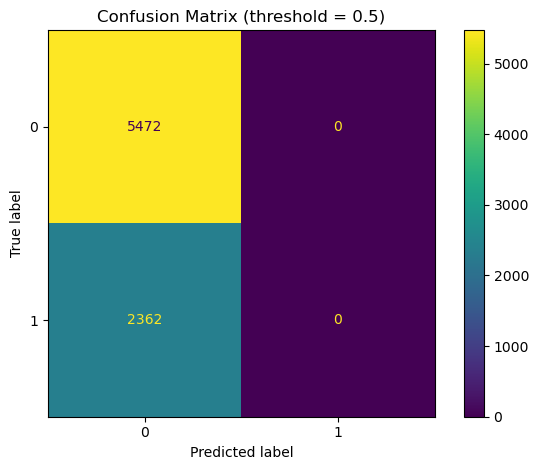

In [287]:
stack.fit(X_train, y_train)
probs = stack.predict_proba(X_test)[:, 1]

preds = (probs > 0.5).astype(int)
print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix (threshold = 0.5)")
plt.tight_layout()
plt.show()

### 7.6 Tune Decision Threshold on a Validation Split

In [288]:
# Split training data into train / validation for threshold tuning
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Retrain on reduced training set to get validation probabilities
stack.fit(X_tr, y_tr)
val_probs = stack.predict_proba(X_val)[:, 1]

# Find threshold that maximises F1 on validation set
best_t, best_f1 = 0.5, 0.0
for t in np.arange(0.1, 0.9, 0.01):
    temp_preds = (val_probs > t).astype(int)
    score = f1_score(y_val, temp_preds)
    if score > best_f1:
        best_f1, best_t = score, t

print(f"Best threshold (from validation set): {best_t:.2f}")
print(f"Best F1 on validation set: {best_f1:.4f}")

Best threshold (from validation set): 0.22
Best F1 on validation set: 0.4632


### 7.7 Final Evaluation on Test Set (Using Best Threshold)

Evaluation with threshold = 0.22

              precision    recall  f1-score   support

           0       1.00      0.00      0.00      5472
           1       0.30      1.00      0.46      2362

    accuracy                           0.30      7834
   macro avg       0.65      0.50      0.23      7834
weighted avg       0.79      0.30      0.14      7834

ROC-AUC: 0.508


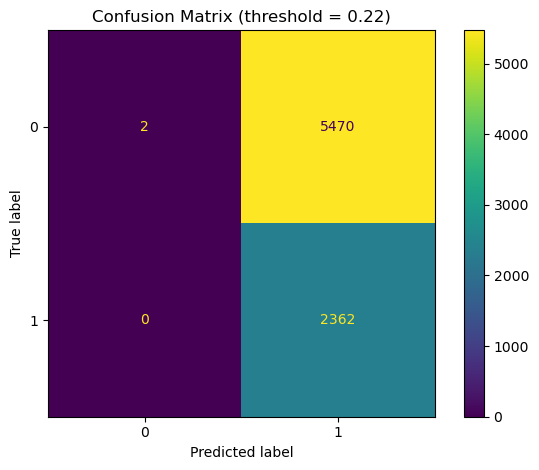

In [289]:
# Retrain on full training set, apply best threshold to untouched test set
stack.fit(X_train, y_train)
test_probs = stack.predict_proba(X_test)[:, 1]
final_preds = (test_probs > best_t).astype(int)

print(f"Evaluation with threshold = {best_t:.2f}\n")
print(classification_report(y_test, final_preds))
print("ROC-AUC:", roc_auc_score(y_test, test_probs).round(4))

cm = confusion_matrix(y_test, final_preds)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title(f"Confusion Matrix (threshold = {best_t:.2f})")
plt.tight_layout()
plt.show()

### 7.8 Hyperparameter Tuning (Balanced Random Forest)

In [291]:
# param_dist = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [None, 10, 15],
#     'min_samples_leaf': [1, 2, 5],
#     'max_features': ['sqrt', 0.5]
# }

# random_search = RandomizedSearchCV(
#     estimator=BalancedRandomForestClassifier(random_state=254),
#     param_distributions=param_dist,
#     n_iter=15,
#     scoring='f1',
#     cv=3,
#     verbose=1,
#     random_state=42,
#     n_jobs=-1
# )
# random_search.fit(X_train, y_train)

# print("Best params:", random_search.best_params_)
# print("Best CV F1 score:", round(random_search.best_score_, 4))

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.ensemble import BalancedRandomForestClassifier

# ============================================
# 1. DEFINE FEATURES (MATCH YOUR DATA)
# ============================================

categorical_cols = [
    'Gender',
    'County',
    'CourseCategory',
    'LoanStatus',
    'Sponsored'
]

numeric_cols = [
    'ProgramCost',
    'TotalLoanAllocated',
    'ScholarshipApplied',
    'EnrollmentAge'
]

# ============================================
# 2. PREPROCESSOR
# ============================================

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
])

# ============================================
# 3. PIPELINE (THIS IS THE FIX)
# ============================================

brf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', BalancedRandomForestClassifier(random_state=254))
])

# ============================================
# 4. PARAM GRID (IMPORTANT: PREFIX model__)
# ============================================

param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 15],
    'model__min_samples_leaf': [1, 2, 5],
    'model__max_features': ['sqrt', 0.5]
}

# ============================================
# 5. RANDOM SEARCH
# ============================================

random_search = RandomizedSearchCV(
    estimator=brf_pipeline,
    param_distributions=param_dist,
    n_iter=15,
    scoring='f1',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# ============================================
# 6. FIT (NOW SAFE)
# ============================================

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV F1 score:", round(random_search.best_score_, 4))

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'model__n_estimators': 100, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}
Best CV F1 score: 0.3774


### 7.9 Evaluate Tuned Stack with Best RFC Params

In [292]:
tuned_rfc = random_search.best_estimator_

stack_tuned = StackingClassifier(
    estimators=[
        ('rfc', tuned_rfc),
        ('lr', lr_pipeline)
    ],
    final_estimator=XGBClassifier(eval_metric='logloss', random_state=42),
    stack_method='predict_proba',
    cv=5,
    n_jobs=-1
)

stack_tuned.fit(X_train, y_train)
tuned_probs = stack_tuned.predict_proba(X_test)[:, 1]
tuned_preds = (tuned_probs > best_t).astype(int)

print(f"Tuned Stack — threshold = {best_t:.2f}\n")
print(classification_report(y_test, tuned_preds))
print("ROC-AUC:", roc_auc_score(y_test, tuned_probs).round(4))

cm_tuned = confusion_matrix(y_test, tuned_preds)
ConfusionMatrixDisplay(confusion_matrix=cm_tuned).plot()
plt.title("Tuned Stack — Confusion Matrix")
plt.tight_layout()
plt.show()

ValueError: could not convert string to float: 'Female'

In [293]:
import joblib

best_xgb = xgb_search.best_estimator_

joblib.dump(best_xgb, "best_xgb.pkl")

print("Model saved successfully")

Model saved successfully


In [294]:
import pickle

# We use 'best_xgb' because that is the variable name in your memory
try:
    with open('model.pkl', 'wb') as f:
        pickle.dump(best_xgb, f)
    print("Success! 'model.pkl' has been created in your folder.")
except NameError:
    print("Error: 'best_xgb' was not found. Please run the cell where you trained/defined 'best_xgb' first.")

Success! 'model.pkl' has been created in your folder.


In [ ]:
!pip install xgboost

In [295]:
import joblib

model = joblib.load("best_xgb.pkl")
print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
!python -m pip install xgboost

In [296]:
import joblib

model = joblib.load("best_xgb.pkl")
print(type(model))

<class 'xgboost.sklearn.XGBClassifier'>


In [297]:
import joblib
import os

print("Loading model from:", os.path.abspath("best_xgb.pkl"))

model = joblib.load("best_xgb.pkl")

print(type(model))

Loading model from: c:\Users\geoff\OneDrive\Desktop\Student_dropout_prediction_project\best_xgb.pkl
<class 'xgboost.sklearn.XGBClassifier'>


In [304]:
import joblib

model = joblib.load("best_xgb.pkl")

print(model)
print(type(model))

print(model.steps)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'County',
                                                   'CourseCategory',
                                                   'LoanStatus', 'Sponsored']),
                                                 ('num', StandardScaler(),
                                                  ['ProgramCost',
                                                   'TotalLoanAllocated',
                                                   'ScholarshipApplied',
                                                   'EnrollmentAge'])])),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsa...
                               feature_types=None, feature_weights=None,
                    

In [303]:
import joblib

model = joblib.load("best_xgb.pkl")

print(type(model))
print(model)
print(model.named_steps)

<class 'sklearn.pipeline.Pipeline'>
Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'County',
                                                   'CourseCategory',
                                                   'LoanStatus', 'Sponsored']),
                                                 ('num', StandardScaler(),
                                                  ['ProgramCost',
                                                   'TotalLoanAllocated',
                                                   'ScholarshipApplied',
                                                   'EnrollmentAge'])])),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsa...
                               feature_types=None, featur